### Libraries and System Parameters

In [1]:
import numpy as np
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
import os
import gc 

# Physical parameters of the Inverted Cart Pendulum system
M = 1.0     # Mass of the cart (kg)
m = 0.1     # Mass of the pendulum (kg)
l = 0.5     # Length to the pendulum's center of mass (m)
g = 9.81    # Gravity acceleration (m/s^2)

# Viscous friction coefficients for realistic damping
b_c = 0.1   # Friction coefficient of the cart (N*s/m)
b_p = 0.01  # Friction coefficient of the pendulum joint (N*m*s/rad)

print("Cell 1 Updated: Physical constants defined with realistic friction.")

Cell 1 Updated: Physical constants defined with realistic friction.


### Dynamics of the Inverted Cart Pendulum

The continuous-time dynamics of the frictionless inverted pendulum on a cart are derived using Lagrangian mechanics. The system is defined by two second-order nonlinear differential equations representing the cart's linear acceleration ($\ddot{x}$) and the pendulum's angular acceleration ($\ddot{\theta}$).

**1. Cart Acceleration ($\ddot{x}$):**
$$ \ddot{x} = \frac{F + ml\dot{\theta}^2\sin\theta - mg\sin\theta\cos\theta}{M + m\sin^2\theta} $$

**2. Pendulum Angular Acceleration ($\ddot{\theta}$):**
$$ \ddot{\theta} = \frac{(M+m)g\sin\theta - F\cos\theta - ml\dot{\theta}^2\sin\theta\cos\theta}{l(M + m\sin^2\theta)} $$

**Why Sine and Cosine?**
* **$mg\sin\theta$** : Represents the component of the gravitational force pulling the pendulum downwards along its rotational arc. When upright ($\theta=0$), this force is zero. When horizontal ($\theta=90^\circ$ or $\pi/2$), it is at its maximum.
* **$ml\dot{\theta}^2\sin\theta$** : Represents the centrifugal force generated by the pendulum's rotation, which pushes or pulls the cart horizontally depending on the angle.
* **$\cos\theta$ terms** : These project the horizontal force of the cart ($F$) onto the rotational axis of the pendulum. A horizontal force has maximum impact on the pendulum when it is upright ($100\%$ projection, $\cos(0)=1$), and zero impact when the pendulum is horizontal ($\cos(90^\circ)=0$).
* **$M + m\sin^2\theta$** : This is the effective mass of the system in the horizontal direction. It dynamically changes because the pendulum's mass ($m$) acts differently on the cart depending on its angle.

In [3]:
def cart_pendulum_dynamics(state, force):
    x, x_dot, theta, theta_dot = state
    
    sin_theta = np.sin(theta)
    cos_theta = np.cos(theta)
    
    denominator = M + m * (sin_theta ** 2)
    
    # Calculate cart acceleration (x_acc) with friction
    x_acc = (force - b_c * x_dot + m * l * (theta_dot ** 2) * sin_theta 
             - m * g * sin_theta * cos_theta + (b_p / l) * theta_dot * cos_theta) / denominator
    
    # Calculate pendulum angular acceleration (theta_acc) with friction
    theta_acc = ((M + m) * g * sin_theta - cos_theta * (force - b_c * x_dot + m * l * (theta_dot ** 2) * sin_theta) 
                 - ((M + m) / (m * l)) * b_p * theta_dot) / (l * denominator)
    
    return np.array([x_dot, x_acc, theta_dot, theta_acc])

print("Cell 2 Updated: Continuous dynamics function updated with friction components.")

Cell 2 Updated: Continuous dynamics function updated with friction components.


### Runge-Kutta 4 (RK4) Integration

To transition from continuous-time dynamics to discrete-time steps, we use the 4th-order Runge-Kutta (RK4) method. It provides a highly accurate approximation of the next state by evaluating the continuous dynamics function $f(x, u)$ at four different points within a single time step $\Delta t$:

1. $k_1 = f(s_t, u_t)$  *(Slope at the beginning of the step)*
2. $k_2 = f(s_t + \frac{\Delta t}{2} k_1, u_t)$ *(Slope at the midpoint using $k_1$)*
3. $k_3 = f(s_t + \frac{\Delta t}{2} k_2, u_t)$ *(Slope at the midpoint using $k_2$)*
4. $k_4 = f(s_t + \Delta t \cdot k_3, u_t)$ *(Slope at the end of the step using $k_3$)*

**Discrete Next State ($s_{t+1}$):**
$$ s_{t+1} = s_t + \frac{\Delta t}{6} (k_1 + 2k_2 + 2k_3 + k_4) $$

In [4]:
# ---------------------------------------------------------
# Cell 3: Runge-Kutta 4 (RK4) Integration Method
# ---------------------------------------------------------

def rk4_step(state, force, dt=0.02):
    """
    Computes the next state of the system using the 4th-order Runge-Kutta method.
    Converts continuous-time dynamics into discrete-time state transitions.
    
    Parameters:
    state (numpy.array): The current state vector [x, x_dot, theta, theta_dot]
    force (float): The control input force applied to the cart (Newtons)
    dt (float): The discrete time step for integration (seconds). Default is 0.02s.
    
    Returns:
    numpy.array: The next state vector after dt seconds [x_n, x_dot_n, theta_n, theta_dot_n]
    """
    # k1: derivative at the current state
    k1 = cart_pendulum_dynamics(state, force)
    
    # k2: derivative at the midpoint using k1
    state_k2 = state + (dt / 2.0) * k1
    k2 = cart_pendulum_dynamics(state_k2, force)
    
    # k3: derivative at the midpoint using k2
    state_k3 = state + (dt / 2.0) * k2
    k3 = cart_pendulum_dynamics(state_k3, force)
    
    # k4: derivative at the end of the step using k3
    state_k4 = state + dt * k3
    k4 = cart_pendulum_dynamics(state_k4, force)
    
    # Calculate the weighted average of the slopes to find the next state
    next_state = state + (dt / 6.0) * (k1 + 2.0 * k2 + 2.0 * k3 + k4)
    
    # Normalize theta to remain within the range [-pi, pi] to prevent 
    # the angle from growing infinitely if it spins multiple times.
    # We want 360 degrees to wrap around smoothly.
    # next_state[2] is theta.
    next_state[2] = (next_state[2] + np.pi) % (2 * np.pi) - np.pi
    
    return next_state

print("Cell 3 executed: RK4 integration method (rk4_step) defined.")

Cell 3 executed: RK4 integration method (rk4_step) defined.


### Dataset Generation and Export

In [12]:
# ---------------------------------------------------------
# Cell 4: Dataset Generation with Chunking
# ---------------------------------------------------------
import os
import gc

# 1. Setup export directory and file path
export_dir = "exports"
os.makedirs(export_dir, exist_ok=True)
parquet_file_path = os.path.join(export_dir, "inverted_pendulum_dataset.parquet")

# 2. Simulation Hyperparameters
NUM_TRAJECTORIES = 10000
STEPS_PER_TRAJECTORY = 1000
CHUNK_SIZE = 100 # Process 100 trajectories per chunk (100,000 rows at a time)
TOTAL_CHUNKS = NUM_TRAJECTORIES // CHUNK_SIZE

# Define the schema explicitly for the PyArrow writer
schema = pa.schema([
    ('x', pa.float32()),
    ('x_dot', pa.float32()),
    ('theta', pa.float32()),
    ('theta_dot', pa.float32()),
    ('force', pa.float32()),
    ('x_next', pa.float32()),
    ('x_dot_next', pa.float32()),
    ('theta_next', pa.float32()),
    ('theta_dot_next', pa.float32())
])

# Remove the file if it already exists to avoid appending to old data
if os.path.exists(parquet_file_path):
    os.remove(parquet_file_path)

print(f"Starting dataset generation: {NUM_TRAJECTORIES} trajectories, {STEPS_PER_TRAJECTORY} steps each.")
print(f"Total target rows: {NUM_TRAJECTORIES * STEPS_PER_TRAJECTORY:,}")
print("---")

# 3. Open a ParquetWriter object
with pq.ParquetWriter(parquet_file_path, schema) as writer:
    
    for chunk in range(TOTAL_CHUNKS):
        chunk_data = []
        
        for traj in range(CHUNK_SIZE):
            # Random initial state for each trajectory
            # x between -2.0 and 2.0
            # x_dot between -1.0 and 1.0
            # theta between -pi and pi (360 degree coverage)
            # theta_dot between -2.0 and 2.0
            state = np.array([
                np.random.uniform(-2.0, 2.0),
                np.random.uniform(-1.0, 1.0),
                np.random.uniform(-np.pi, np.pi),
                np.random.uniform(-2.0, 2.0)
            ], dtype=np.float32)
            
            steps_remaining_for_current_force = 0
            current_force = 0.0
            
            for step in range(STEPS_PER_TRAJECTORY):
                # Force logic: hold force for a random duration, then switch
                if steps_remaining_for_current_force == 0:
                    steps_remaining_for_current_force = np.random.randint(20, 100)
                    
                    # 40% chance of ZERO force (free-fall / gravity only)
                    # 60% chance of random force in [-1, 1]
                    if np.random.rand() < 0.4:
                        current_force = 0.0
                    else:
                        current_force = np.random.uniform(-1.0, 1.0)
                
                # Calculate the next state using RK4
                next_state = rk4_step(state, current_force, dt=0.02)
                
                # Append a single row of data
                chunk_data.append((
                    state[0], state[1], state[2], state[3],
                    current_force,
                    next_state[0], next_state[1], next_state[2], next_state[3]
                ))
                
                # Update current state and decrement force duration
                state = next_state
                steps_remaining_for_current_force -= 1
        
        # Convert chunk data to pandas DataFrame, then to PyArrow Table
        columns = ['x', 'x_dot', 'theta', 'theta_dot', 'force', 
                   'x_next', 'x_dot_next', 'theta_next', 'theta_dot_next']
        
        # Use float32 to save disk space and RAM (highly recommended for Deep Learning)
        df_chunk = pd.DataFrame(chunk_data, columns=columns).astype(np.float32)
        table = pa.Table.from_pandas(df_chunk, schema=schema)
        
        # Write the chunk to the parquet file
        writer.write_table(table)
        
        # Clear memory explicitly to prevent RAM overload on your 12GB system
        del chunk_data
        del df_chunk
        del table
        gc.collect()
        
        # Print progress every 10 chunks
        if (chunk + 1) % 10 == 0:
            print(f"Processed {(chunk + 1) * CHUNK_SIZE} / {NUM_TRAJECTORIES} trajectories...")

print("---")
print(f"Dataset generation complete! File saved securely at: {parquet_file_path}")

Starting dataset generation: 10000 trajectories, 1000 steps each.
Total target rows: 10,000,000
---
Processed 1000 / 10000 trajectories...
Processed 2000 / 10000 trajectories...
Processed 3000 / 10000 trajectories...
Processed 4000 / 10000 trajectories...
Processed 5000 / 10000 trajectories...
Processed 6000 / 10000 trajectories...
Processed 7000 / 10000 trajectories...
Processed 8000 / 10000 trajectories...
Processed 9000 / 10000 trajectories...
Processed 10000 / 10000 trajectories...
---
Dataset generation complete! File saved securely at: exports/inverted_pendulum_dataset.parquet


### Cell 5: Dataset Verification and Integrity Check

In [15]:
# ---------------------------------------------------------
# Cell 5: Dataset Verification
# ---------------------------------------------------------
import pandas as pd
import numpy as np
import os

parquet_file_path = os.path.join("exports", "inverted_pendulum_dataset.parquet")

# Load the entire dataset into memory. 
# Thanks to float32, this should only take ~360 MB of RAM.
print("Loading dataset into pandas...")
df = pd.read_parquet(parquet_file_path)

# 1. Check basic structure
print(f"Dataset Shape: {df.shape}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / (1024**2):.2f} MB")

# 2. Display the first 5 rows to verify the values
print("\nFirst 5 rows of the dataset:")
display(df.head())

# 3. Integrity Check: Look for NaN or Infinite values
# Deep Learning models will output NaN loss if there is even one NaN/Inf in the dataset.
has_nans = df.isna().any().any()
has_infs = np.isinf(df).any().any()

print("\n--- Integrity Check ---")
print(f"Contains NaN values: {has_nans}")
print(f"Contains Infinite values: {has_infs}")

if has_nans or has_infs:
    print("WARNING: Dataset contains invalid values. We must clean it before training!")
else:
    print("SUCCESS: Dataset is perfectly clean and ready for Deep Learning.")

print("\nCell 5 executed: Dataset verification complete.")

Loading dataset into pandas...
Dataset Shape: (10000000, 9)
Memory Usage: 343.32 MB

First 5 rows of the dataset:


,x,x_dot,theta,theta_dot,force,x_next,x_dot_next,theta_next,theta_dot_next
0,1.951561,-0.492866,2.940964,-1.101839,0.698218,1.941898,-0.473367,2.920202,-0.973137
1,1.941898,-0.473367,2.920202,-0.973137,0.698218,1.932627,-0.453672,2.902083,-0.837827
2,1.932627,-0.453672,2.902083,-0.837827,0.698218,1.923752,-0.433838,2.886725,-0.697125
3,1.923752,-0.433838,2.886725,-0.697125,0.698218,1.915274,-0.413919,2.874226,-0.552247
4,1.915274,-0.413919,2.874226,-0.552247,0.698218,1.907196,-0.393961,2.864656,-0.404403



--- Integrity Check ---
Contains NaN values: False
Contains Infinite values: False
SUCCESS: Dataset is perfectly clean and ready for Deep Learning.

Cell 5 executed: Dataset verification complete.


### PyTorch & CUDA Setup and DataLoader Preparation

In [22]:
# ---------------------------------------------------------
# Cell 6 Update: Pure Tensor Operations (Bypassing DataLoader)
# ---------------------------------------------------------
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")



# 1. Delta Learning Setup
X_np = df[['x', 'x_dot', 'theta', 'theta_dot', 'force']].values

# Normal delta calculation for x, x_dot, and theta_dot
y_np = df[['x_next', 'x_dot_next', 'theta_next', 'theta_dot_next']].values - df[['x', 'x_dot', 'theta', 'theta_dot']].values

# CRITICAL FIX: Normalize the delta for theta (index 2) to be within [-pi, pi]
# This prevents teaching the network that a jump from +3.14 to -3.14 is a -6.28 change.
y_np[:, 2] = (y_np[:, 2] + np.pi) % (2 * np.pi) - np.pi

# 2. Move to GPU VRAM directly
X_tensor = torch.tensor(X_np, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y_np, dtype=torch.float32).to(device)

# 3. Shuffle the entire dataset rapidly on the GPU
print("Shuffling data on GPU...")
indices = torch.randperm(len(X_tensor), device=device)
X_tensor = X_tensor[indices]
y_tensor = y_tensor[indices]

# 4. Pure Array Slicing for Train/Val split (Lightning fast)
train_size = int(0.8 * len(X_tensor))

X_train = X_tensor[:train_size]
y_train = y_tensor[:train_size]

X_val = X_tensor[train_size:]
y_val = y_tensor[train_size:]

BATCH_SIZE = 16384

print(f"Data cached and split. Train size: {len(X_train)}, Val size: {len(X_val)}")
print("Cell 6 executed: Pure Tensor setup ready.")

Using device: cuda
Shuffling data on GPU...
Data cached and split. Train size: 8000000, Val size: 2000000
Cell 6 executed: Pure Tensor setup ready.


### Neural Network Architecture

In [17]:
# ---------------------------------------------------------
# Cell 7: Neural Network Architecture (MILP Compatible)
# ---------------------------------------------------------
import torch.nn as nn

class InvertedPendulumNN(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, output_size=4):
        """
        Neural Network for predicting the next state of the inverted pendulum.
        Architecture is strictly designed with ReLU to be MILP-compatible for MPC.
        Mapping: R^5 -> R^hidden -> R^hidden -> R^4
        """
        super(InvertedPendulumNN, self).__init__()
        
        # We strictly use 2 hidden layers as planned.
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )
        
    def forward(self, x):
        return self.network(x)

# Initialize the model and move it to the discrete GPU (GTX 1050)
hidden_neurons = 64
model = InvertedPendulumNN(hidden_size=hidden_neurons).to(device)

print(f"Model initialized and moved to {device}.")
print(model)
print("\nTotal trainable parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))
print("Cell 7 executed: Model architecture defined.")

Model initialized and moved to cuda.
InvertedPendulumNN(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=4, bias=True)
  )
)

Total trainable parameters: 4804
Cell 7 executed: Model architecture defined.


### Training Loop (Memory Safe)

In [23]:
# ---------------------------------------------------------
# Cell 8 Update: Tensor Training with LR Scheduler (Fixed)
# ---------------------------------------------------------
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time

def train_model_with_scheduler(model, X_train, y_train, X_val, y_val, epochs=200, batch_size=4096, initial_lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=initial_lr)
    
    # Removed verbose=True to comply with newer PyTorch versions
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
    
    num_train_samples = len(X_train)
    num_val_samples = len(X_val)
    
    print(f"Starting training for {epochs} epochs with Batch Size {batch_size}...")
    start_time = time.time()
    
    for epoch in range(epochs):
        model.train()
        running_train_loss = 0.0
        
        # GPU Shuffling
        perm = torch.randperm(num_train_samples, device=device)
        X_train_shuffled = X_train[perm]
        y_train_shuffled = y_train[perm]
        
        num_batches = 0
        for i in range(0, num_train_samples, batch_size):
            inputs = X_train_shuffled[i:i+batch_size]
            targets = y_train_shuffled[i:i+batch_size]
            
            optimizer.zero_grad()
            predictions = model(inputs)
            loss = criterion(predictions, targets)
            loss.backward()
            optimizer.step()
            
            running_train_loss += loss.item()
            num_batches += 1
            
        epoch_train_loss = running_train_loss / num_batches
        
        # Validation Phase
        model.eval()
        running_val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for i in range(0, num_val_samples, batch_size):
                inputs = X_val[i:i+batch_size]
                targets = y_val[i:i+batch_size]
                
                predictions = model(inputs)
                loss = criterion(predictions, targets)
                running_val_loss += loss.item()
                val_batches += 1
                
        epoch_val_loss = running_val_loss / val_batches
        
        # Step the scheduler using the validation loss
        scheduler.step(epoch_val_loss)
        
        # Print progress and current learning rate every 10 epochs
        if (epoch + 1) % 10 == 0 or epoch == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch [{epoch+1}/{epochs}] - Train Loss: {epoch_train_loss:.7f} - Val Loss: {epoch_val_loss:.7f} - LR: {current_lr:.6f}")
        
    total_time = time.time() - start_time
    print(f"\nTraining completed in {total_time / 60:.2f} minutes!")

# Reset model to destroy old bad weights
model = InvertedPendulumNN(hidden_size=64).to(device)

# Run the highly optimized training
train_model_with_scheduler(model, X_train, y_train, X_val, y_val, epochs=200, batch_size=4096)

Starting training for 200 epochs with Batch Size 4096...
Epoch [1/200] - Train Loss: 0.0008657 - Val Loss: 0.0000343 - LR: 0.001000
Epoch [10/200] - Train Loss: 0.0000044 - Val Loss: 0.0000021 - LR: 0.001000
Epoch [20/200] - Train Loss: 0.0000017 - Val Loss: 0.0000011 - LR: 0.001000
Epoch [30/200] - Train Loss: 0.0000005 - Val Loss: 0.0000011 - LR: 0.000500
Epoch [40/200] - Train Loss: 0.0000004 - Val Loss: 0.0000002 - LR: 0.000500
Epoch [50/200] - Train Loss: 0.0000003 - Val Loss: 0.0000003 - LR: 0.000500
Epoch [60/200] - Train Loss: 0.0000002 - Val Loss: 0.0000002 - LR: 0.000250
Epoch [70/200] - Train Loss: 0.0000001 - Val Loss: 0.0000001 - LR: 0.000250
Epoch [80/200] - Train Loss: 0.0000001 - Val Loss: 0.0000002 - LR: 0.000250
Epoch [90/200] - Train Loss: 0.0000001 - Val Loss: 0.0000001 - LR: 0.000125
Epoch [100/200] - Train Loss: 0.0000001 - Val Loss: 0.0000001 - LR: 0.000125
Epoch [110/200] - Train Loss: 0.0000001 - Val Loss: 0.0000001 - LR: 0.000063
Epoch [120/200] - Train Loss: 

### Free-Fall Multi-Step Rollout Simulation (2x2 Grid & Delta Logic)

<>:70: SyntaxWarning: invalid escape sequence '\d'
<>:87: SyntaxWarning: invalid escape sequence '\d'
<>:70: SyntaxWarning: invalid escape sequence '\d'
<>:87: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_30521/2804873117.py:70: SyntaxWarning: invalid escape sequence '\d'
  axs[0, 1].set_title('Cart Velocity ($\dot{x}$)')
/tmp/ipykernel_30521/2804873117.py:87: SyntaxWarning: invalid escape sequence '\d'
  axs[1, 1].set_title('Angular Velocity ($\dot{\\theta}$)')


Running 2x2 Grid Multi-Step Rollout Simulation...


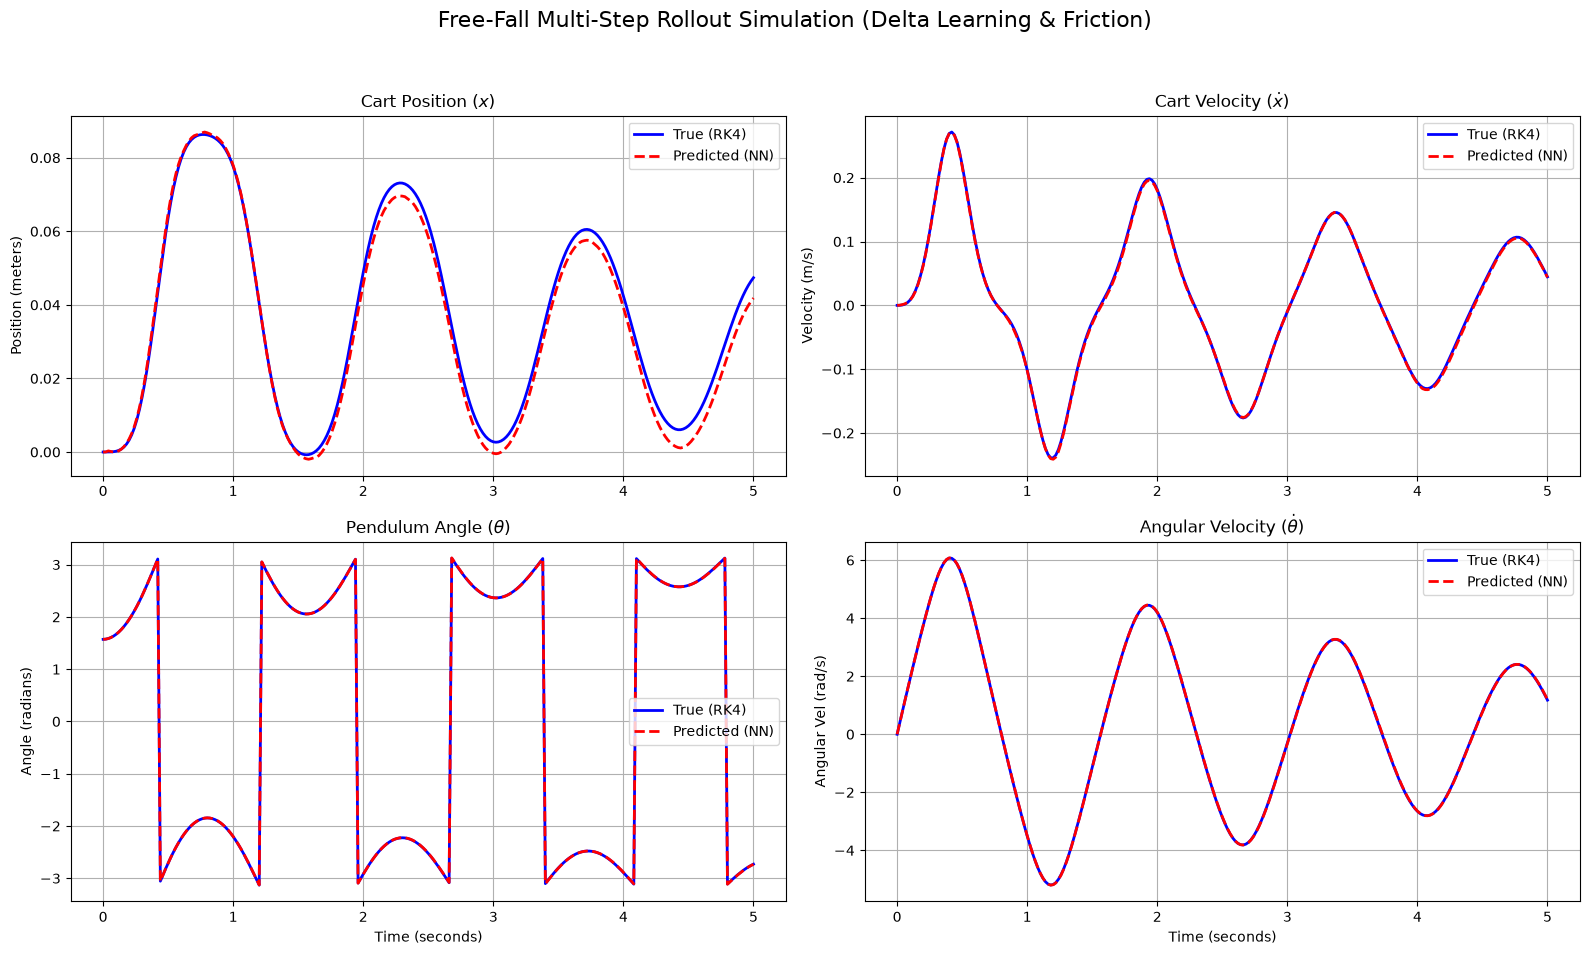

Cell 9 executed: 2x2 Grid Simulation completed.


In [24]:
# ---------------------------------------------------------
# Cell 9: Free-Fall Multi-Step Rollout (Delta Predictions)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Simulation Setup
time_steps = 250      # 250 steps * 0.02s = 5.0 seconds
dt = 0.02
applied_force = 0.0   # Zero force for free-fall

# Initial State: Cart at center, Pendulum released from 90 degrees (pi/2)
initial_state = np.array([0.0, 0.0, np.pi/2, 0.0], dtype=np.float32)

true_trajectory = [initial_state]
pred_trajectory = [initial_state]

current_true_state = initial_state.copy()
current_pred_state = initial_state.copy()

print("Running 2x2 Grid Multi-Step Rollout Simulation...")

model.eval()

# 2. Run the Simulation Loop
with torch.no_grad():
    for step in range(time_steps):
        # --- TRUE PHYSICS (RK4) ---
        next_true_state = rk4_step(current_true_state, applied_force, dt)
        true_trajectory.append(next_true_state)
        current_true_state = next_true_state
        
        # --- PREDICTED PHYSICS (Neural Network) ---
        nn_input_np = np.append(current_pred_state, applied_force).astype(np.float32)
        nn_input_tensor = torch.tensor(nn_input_np).unsqueeze(0).to(device)
        
        # CRITICAL UPDATE: The model predicts the DELTA (change), not the absolute state
        predicted_delta = model(nn_input_tensor).cpu().numpy()[0]
        
        # Next State = Current State + Predicted Delta
        next_pred_state = current_pred_state + predicted_delta
        
        # Normalize the angle to [-pi, pi] to maintain physical boundaries
        next_pred_state[2] = (next_pred_state[2] + np.pi) % (2 * np.pi) - np.pi
        
        pred_trajectory.append(next_pred_state)
        current_pred_state = next_pred_state

# Convert to numpy arrays for plotting
true_trajectory = np.array(true_trajectory)
pred_trajectory = np.array(pred_trajectory)
time_axis = np.linspace(0, time_steps * dt, time_steps + 1)

# 3. Visualization: 2x2 Grid
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Free-Fall Multi-Step Rollout Simulation (Delta Learning & Friction)', fontsize=16)

# Plot 1: Cart Position (x)
axs[0, 0].plot(time_axis, true_trajectory[:, 0], label='True (RK4)', color='blue', linewidth=2)
axs[0, 0].plot(time_axis, pred_trajectory[:, 0], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[0, 0].set_title('Cart Position ($x$)')
axs[0, 0].set_ylabel('Position (meters)')
axs[0, 0].grid(True)
axs[0, 0].legend()

# Plot 2: Cart Velocity (x_dot)
axs[0, 1].plot(time_axis, true_trajectory[:, 1], label='True (RK4)', color='blue', linewidth=2)
axs[0, 1].plot(time_axis, pred_trajectory[:, 1], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[0, 1].set_title('Cart Velocity ($\dot{x}$)')
axs[0, 1].set_ylabel('Velocity (m/s)')
axs[0, 1].grid(True)
axs[0, 1].legend()

# Plot 3: Pendulum Angle (theta)
axs[1, 0].plot(time_axis, true_trajectory[:, 2], label='True (RK4)', color='blue', linewidth=2)
axs[1, 0].plot(time_axis, pred_trajectory[:, 2], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[1, 0].set_title('Pendulum Angle ($\\theta$)')
axs[1, 0].set_xlabel('Time (seconds)')
axs[1, 0].set_ylabel('Angle (radians)')
axs[1, 0].grid(True)
axs[1, 0].legend()

# Plot 4: Angular Velocity (theta_dot)
axs[1, 1].plot(time_axis, true_trajectory[:, 3], label='True (RK4)', color='blue', linewidth=2)
axs[1, 1].plot(time_axis, pred_trajectory[:, 3], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[1, 1].set_title('Angular Velocity ($\dot{\\theta}$)')
axs[1, 1].set_xlabel('Time (seconds)')
axs[1, 1].set_ylabel('Angular Vel (rad/s)')
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to fit the main title
plt.show()

print("Cell 9 executed: 2x2 Grid Simulation completed.")

### Cell 10: 50-Second Free-Fall Rollout Simulation

<>:62: SyntaxWarning: invalid escape sequence '\d'
<>:77: SyntaxWarning: invalid escape sequence '\d'
<>:62: SyntaxWarning: invalid escape sequence '\d'
<>:77: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_30521/513249336.py:62: SyntaxWarning: invalid escape sequence '\d'
  axs[0, 1].set_title('Cart Velocity ($\dot{x}$)')
/tmp/ipykernel_30521/513249336.py:77: SyntaxWarning: invalid escape sequence '\d'
  axs[1, 1].set_title('Angular Velocity ($\dot{\\theta}$)')


Running 50-Second Long-Term Rollout Simulation...


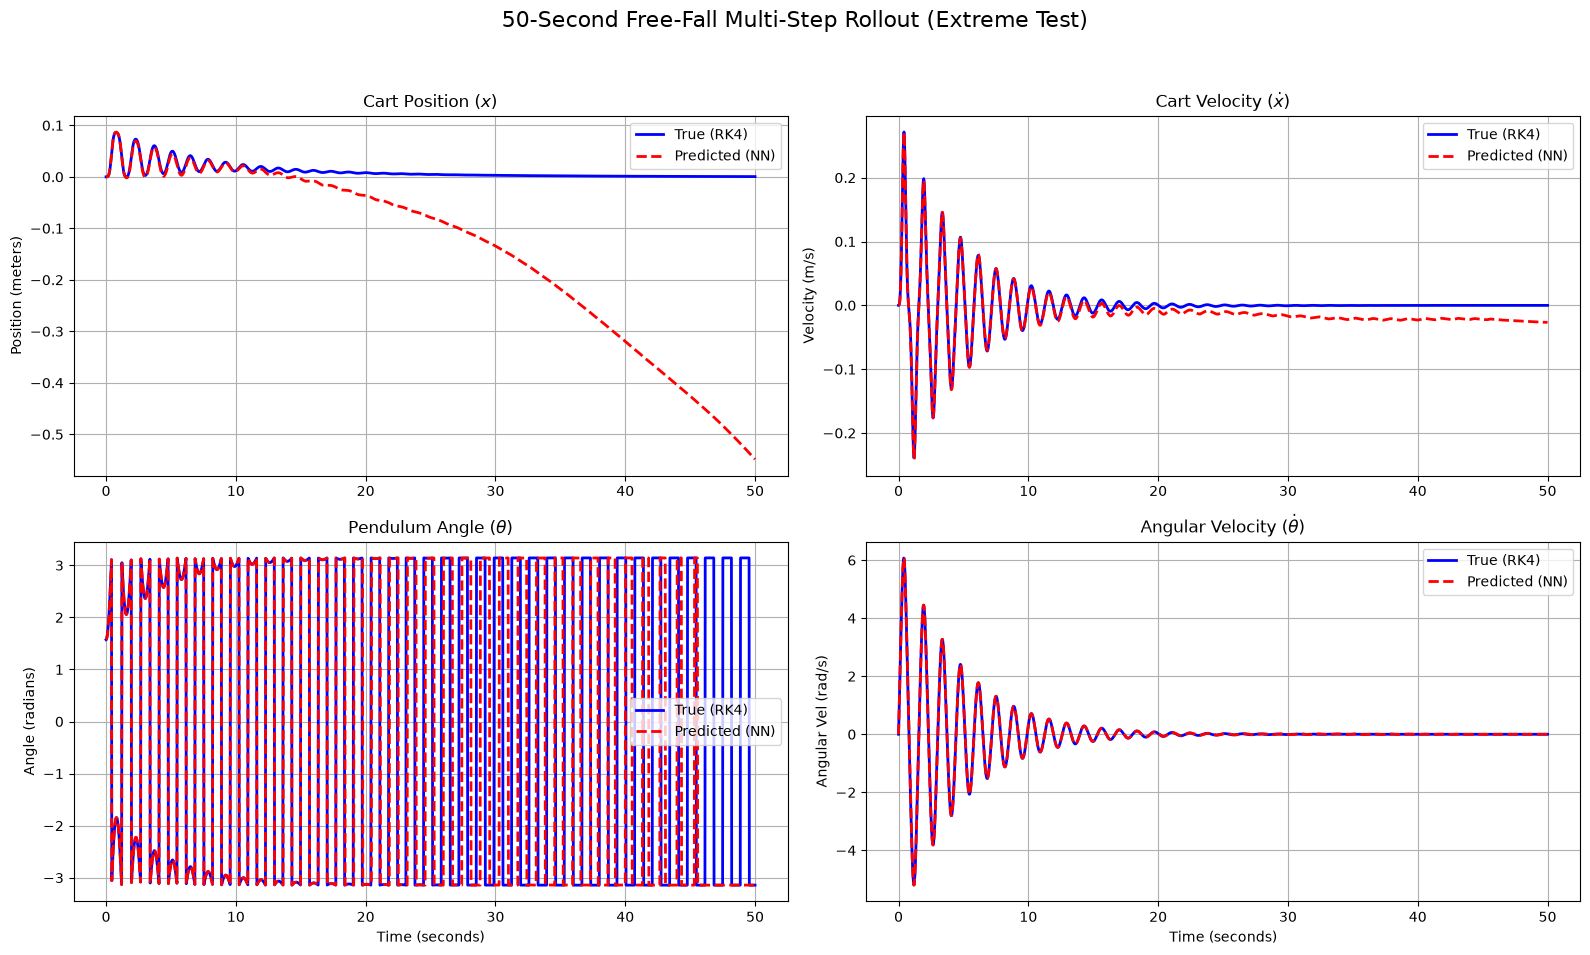

In [25]:
# ---------------------------------------------------------
# Cell 10: 50-Second Long-Term Multi-Step Rollout
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Setup for 50 seconds
time_steps = 2500      # 2500 steps * 0.02s = 50.0 seconds
dt = 0.02
applied_force = 0.0    # Free-fall

initial_state = np.array([0.0, 0.0, np.pi/2, 0.0], dtype=np.float32)

true_trajectory = [initial_state]
pred_trajectory = [initial_state]

current_true_state = initial_state.copy()
current_pred_state = initial_state.copy()

print("Running 50-Second Long-Term Rollout Simulation...")

model.eval()

with torch.no_grad():
    for step in range(time_steps):
        # --- TRUE PHYSICS (RK4) ---
        next_true_state = rk4_step(current_true_state, applied_force, dt)
        true_trajectory.append(next_true_state)
        current_true_state = next_true_state
        
        # --- PREDICTED PHYSICS (Neural Network) ---
        nn_input_np = np.append(current_pred_state, applied_force).astype(np.float32)
        nn_input_tensor = torch.tensor(nn_input_np).unsqueeze(0).to(device)
        
        predicted_delta = model(nn_input_tensor).cpu().numpy()[0]
        next_pred_state = current_pred_state + predicted_delta
        
        # Normalize angle
        next_pred_state[2] = (next_pred_state[2] + np.pi) % (2 * np.pi) - np.pi
        
        pred_trajectory.append(next_pred_state)
        current_pred_state = next_pred_state

true_trajectory = np.array(true_trajectory)
pred_trajectory = np.array(pred_trajectory)
time_axis = np.linspace(0, time_steps * dt, time_steps + 1)

# 2. Visualization
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('50-Second Free-Fall Multi-Step Rollout (Extreme Test)', fontsize=16)

axs[0, 0].plot(time_axis, true_trajectory[:, 0], label='True (RK4)', color='blue', linewidth=2)
axs[0, 0].plot(time_axis, pred_trajectory[:, 0], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[0, 0].set_title('Cart Position ($x$)')
axs[0, 0].set_ylabel('Position (meters)')
axs[0, 0].grid(True)
axs[0, 0].legend()

axs[0, 1].plot(time_axis, true_trajectory[:, 1], label='True (RK4)', color='blue', linewidth=2)
axs[0, 1].plot(time_axis, pred_trajectory[:, 1], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[0, 1].set_title('Cart Velocity ($\dot{x}$)')
axs[0, 1].set_ylabel('Velocity (m/s)')
axs[0, 1].grid(True)
axs[0, 1].legend()

axs[1, 0].plot(time_axis, true_trajectory[:, 2], label='True (RK4)', color='blue', linewidth=2)
axs[1, 0].plot(time_axis, pred_trajectory[:, 2], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[1, 0].set_title('Pendulum Angle ($\\theta$)')
axs[1, 0].set_xlabel('Time (seconds)')
axs[1, 0].set_ylabel('Angle (radians)')
axs[1, 0].grid(True)
axs[1, 0].legend()

axs[1, 1].plot(time_axis, true_trajectory[:, 3], label='True (RK4)', color='blue', linewidth=2)
axs[1, 1].plot(time_axis, pred_trajectory[:, 3], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
axs[1, 1].set_title('Angular Velocity ($\dot{\\theta}$)')
axs[1, 1].set_xlabel('Time (seconds)')
axs[1, 1].set_ylabel('Angular Vel (rad/s)')
axs[1, 1].grid(True)
axs[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

### Cell 11: Random Step-Force Response Simulation

<>:87: SyntaxWarning: invalid escape sequence '\d'
<>:105: SyntaxWarning: invalid escape sequence '\d'
<>:87: SyntaxWarning: invalid escape sequence '\d'
<>:105: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_30521/723089455.py:87: SyntaxWarning: invalid escape sequence '\d'
  ax_xdot.set_title('Cart Velocity ($\dot{x}$)')
/tmp/ipykernel_30521/723089455.py:105: SyntaxWarning: invalid escape sequence '\d'
  ax_thetadot.set_title('Angular Velocity ($\dot{\\theta}$)')


Running Random Step-Force Response Simulation (10 Seconds)...


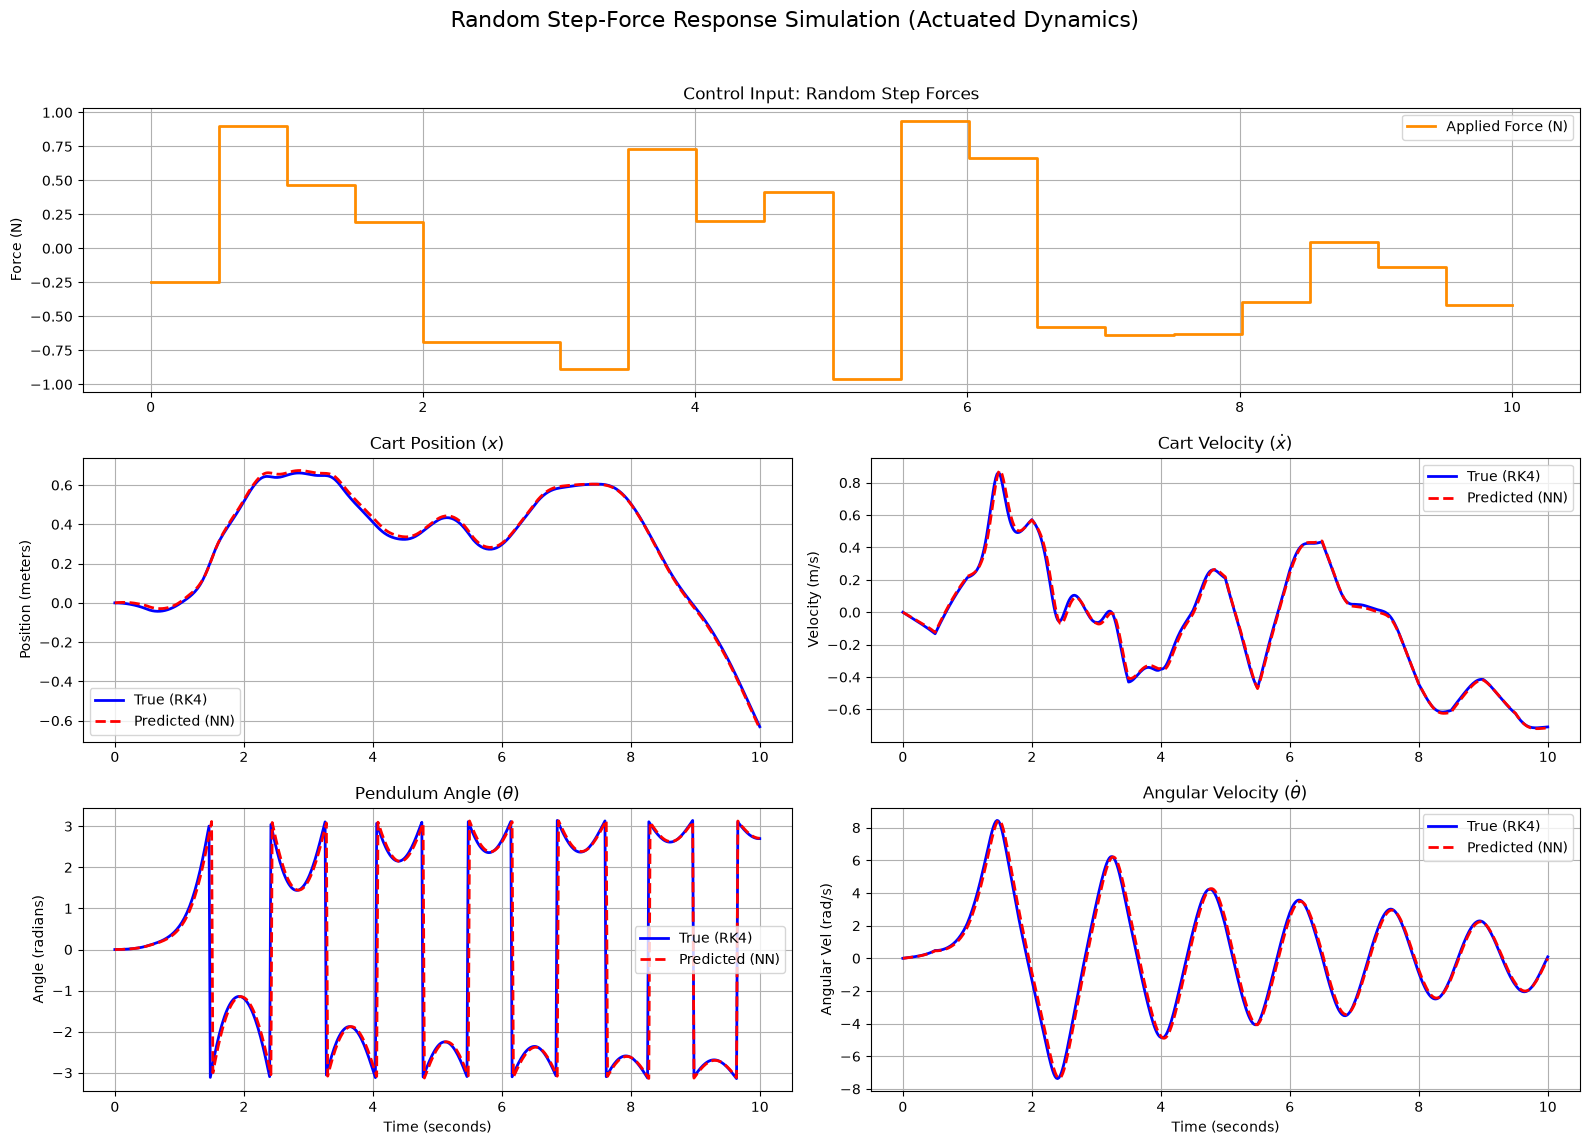

Cell 11 executed: Random Step-Force simulation completed.


In [26]:
# ---------------------------------------------------------
# Cell 11: Random Step-Force Response Simulation
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import torch
import numpy as np

# 1. Setup Simulation Length and Force Profile
time_steps = 500      # 500 steps * 0.02s = 10.0 seconds
dt = 0.02

# Initial State: Pendulum is perfectly upright (0 radians), cart at center
initial_state = np.array([0.0, 0.0, 0.0, 0.0], dtype=np.float32)

true_trajectory = [initial_state]
pred_trajectory = [initial_state]

current_true_state = initial_state.copy()
current_pred_state = initial_state.copy()

# Generate a random force profile: Force changes every 25 steps (0.5 seconds)
np.random.seed(42) # For reproducibility
force_profile = np.zeros(time_steps)
current_force = 0.0
for i in range(time_steps):
    if i % 25 == 0:
        current_force = np.random.uniform(-1.0, 1.0)
    force_profile[i] = current_force

print("Running Random Step-Force Response Simulation (10 Seconds)...")

model.eval()

# 2. Run the Simulation Loop
with torch.no_grad():
    for step in range(time_steps):
        applied_force = force_profile[step]
        
        # --- TRUE PHYSICS (RK4) ---
        next_true_state = rk4_step(current_true_state, applied_force, dt)
        true_trajectory.append(next_true_state)
        current_true_state = next_true_state
        
        # --- PREDICTED PHYSICS (Neural Network) ---
        nn_input_np = np.append(current_pred_state, applied_force).astype(np.float32)
        nn_input_tensor = torch.tensor(nn_input_np).unsqueeze(0).to(device)
        
        # Predict Delta
        predicted_delta = model(nn_input_tensor).cpu().numpy()[0]
        next_pred_state = current_pred_state + predicted_delta
        
        # Normalize angle to [-pi, pi]
        next_pred_state[2] = (next_pred_state[2] + np.pi) % (2 * np.pi) - np.pi
        
        pred_trajectory.append(next_pred_state)
        current_pred_state = next_pred_state

true_trajectory = np.array(true_trajectory)
pred_trajectory = np.array(pred_trajectory)
time_axis_states = np.linspace(0, time_steps * dt, time_steps + 1)
time_axis_force = np.linspace(0, time_steps * dt, time_steps)

# 3. Visualization: Advanced Layout
fig = plt.figure(figsize=(16, 12))
fig.suptitle('Random Step-Force Response Simulation (Actuated Dynamics)', fontsize=16)

# Top Plot: Applied Force
ax_force = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax_force.step(time_axis_force, force_profile, where='post', color='darkorange', linewidth=2, label='Applied Force (N)')
ax_force.set_title('Control Input: Random Step Forces')
ax_force.set_ylabel('Force (N)')
ax_force.grid(True)
ax_force.legend()

# Middle Row: Position and Velocity
ax_x = plt.subplot2grid((3, 2), (1, 0))
ax_x.plot(time_axis_states, true_trajectory[:, 0], label='True (RK4)', color='blue', linewidth=2)
ax_x.plot(time_axis_states, pred_trajectory[:, 0], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
ax_x.set_title('Cart Position ($x$)')
ax_x.set_ylabel('Position (meters)')
ax_x.grid(True)
ax_x.legend()

ax_xdot = plt.subplot2grid((3, 2), (1, 1))
ax_xdot.plot(time_axis_states, true_trajectory[:, 1], label='True (RK4)', color='blue', linewidth=2)
ax_xdot.plot(time_axis_states, pred_trajectory[:, 1], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
ax_xdot.set_title('Cart Velocity ($\dot{x}$)')
ax_xdot.set_ylabel('Velocity (m/s)')
ax_xdot.grid(True)
ax_xdot.legend()

# Bottom Row: Angle and Angular Velocity
ax_theta = plt.subplot2grid((3, 2), (2, 0))
ax_theta.plot(time_axis_states, true_trajectory[:, 2], label='True (RK4)', color='blue', linewidth=2)
ax_theta.plot(time_axis_states, pred_trajectory[:, 2], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
ax_theta.set_title('Pendulum Angle ($\\theta$)')
ax_theta.set_xlabel('Time (seconds)')
ax_theta.set_ylabel('Angle (radians)')
ax_theta.grid(True)
ax_theta.legend()

ax_thetadot = plt.subplot2grid((3, 2), (2, 1))
ax_thetadot.plot(time_axis_states, true_trajectory[:, 3], label='True (RK4)', color='blue', linewidth=2)
ax_thetadot.plot(time_axis_states, pred_trajectory[:, 3], label='Predicted (NN)', color='red', linestyle='dashed', linewidth=2)
ax_thetadot.set_title('Angular Velocity ($\dot{\\theta}$)')
ax_thetadot.set_xlabel('Time (seconds)')
ax_thetadot.set_ylabel('Angular Vel (rad/s)')
ax_thetadot.grid(True)
ax_thetadot.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

print("Cell 11 executed: Random Step-Force simulation completed.")

### Cell 12: Extracting Neural Network Parameters for Gurobi

### MILP Formulation of the Neural Network Dynamics

To embed our trained Neural Network into the Gurobi optimization solver, we must extract its internal weights and biases. The network acts as a constraint in our Model Predictive Control (MPC) formulation, calculating the state change (Delta) for each time step $k$.

The mathematical structure of the neural network inside the optimization problem is defined as follows:

**1. Input Vector:**
The input consists of the current state and the applied control force.
$$ z_0 = [x_k, \dot{x}_k, \theta_k, \dot{\theta}_k, F_k]^T $$

**2. First Hidden Layer (with ReLU):**
The linear transformation is followed by a ReLU activation, which will be modeled in Gurobi using the Big-M method and binary variables.
$$ z_1 = \max(0, W_0 z_0 + b_0) $$
*Where $W_0 \in \mathbb{R}^{64 \times 5}$ and $b_0 \in \mathbb{R}^{64}$.*

**3. Second Hidden Layer (with ReLU):**
$$ z_2 = \max(0, W_1 z_1 + b_1) $$
*Where $W_1 \in \mathbb{R}^{64 \times 64}$ and $b_1 \in \mathbb{R}^{64}$.*

**4. Output Layer (Delta State):**
The final layer calculates the physical state change. Since changes can be negative (e.g., negative velocity), there is no ReLU activation here.
$$ \Delta x = W_2 z_2 + b_2 $$
*Where $W_2 \in \mathbb{R}^{4 \times 64}$ and $b_2 \in \mathbb{R}^4$.*

**5. State Update Equation:**
The next state is calculated by adding the predicted Delta to the current state.
$$ x_{k+1} = x_k + \Delta x $$

In [27]:
# ---------------------------------------------------------
# Cell 12: Extract Neural Network Weights & Biases
# ---------------------------------------------------------
import numpy as np

def extract_nn_parameters(model):
    """
    Extracts weights and biases from the trained PyTorch model 
    and converts them to numpy arrays for Gurobi MILP formulation.
    """
    params = {}
    
    # Ensure model is on CPU for safe numpy conversion
    model_cpu = model.cpu()
    model_cpu.eval()
    
    # Layer 0: First Linear Layer (Input to Hidden 1)
    # network[0] is Linear, network[1] is ReLU
    params['W0'] = model_cpu.network[0].weight.detach().numpy().astype(np.float64)
    params['b0'] = model_cpu.network[0].bias.detach().numpy().astype(np.float64)
    
    # Layer 1: Second Linear Layer (Hidden 1 to Hidden 2)
    # network[2] is Linear, network[3] is ReLU
    params['W1'] = model_cpu.network[2].weight.detach().numpy().astype(np.float64)
    params['b1'] = model_cpu.network[2].bias.detach().numpy().astype(np.float64)
    
    # Layer 2: Output Linear Layer (Hidden 2 to Output)
    # network[4] is Linear (No ReLU)
    params['W2'] = model_cpu.network[4].weight.detach().numpy().astype(np.float64)
    params['b2'] = model_cpu.network[4].bias.detach().numpy().astype(np.float64)
    
    # Put model back to the original device (GPU) if needed later
    model.to(device)
    
    return params

# Extract the parameters
nn_params = extract_nn_parameters(model)

# Verify the shapes mathematically
print("--- Extracted Neural Network Parameters ---")
print(f"W0 shape: {nn_params['W0'].shape} (Expected: 64x5)")
print(f"b0 shape: {nn_params['b0'].shape} (Expected: 64,)")
print(f"W1 shape: {nn_params['W1'].shape} (Expected: 64x64)")
print(f"b1 shape: {nn_params['b1'].shape} (Expected: 64,)")
print(f"W2 shape: {nn_params['W2'].shape} (Expected: 4x64)")
print(f"b2 shape: {nn_params['b2'].shape} (Expected: 4,)")

# Save parameters to disk just in case (optional but highly recommended for reproducibility)
np.savez('exports/nn_gurobi_weights.npz', **nn_params)
print("\nCell 12 executed: Parameters successfully extracted and saved to disk.")

--- Extracted Neural Network Parameters ---
W0 shape: (64, 5) (Expected: 64x5)
b0 shape: (64,) (Expected: 64,)
W1 shape: (64, 64) (Expected: 64x64)
b1 shape: (64,) (Expected: 64,)
W2 shape: (4, 64) (Expected: 4x64)
b2 shape: (4,) (Expected: 4,)

Cell 12 executed: Parameters successfully extracted and saved to disk.


In [5]:
# ---------------------------------------------------------
# RECOVERY CELL: Load pre-trained NN weights for Gurobi
# ---------------------------------------------------------
import numpy as np

# Daha önce Cell 12'de kaydettiğimiz npz dosyasını okuyoruz
loaded_params = np.load('exports/nn_gurobi_weights.npz')

# Gurobi'nin kullanacağı formata (dictionary) çeviriyoruz
nn_params = {key: loaded_params[key] for key in loaded_params.files}

print("Yapay Zeka ağırlıkları başarıyla diskten yüklendi!")
print("W0 shape:", nn_params['W0'].shape)
print("MPC Optimizasyonuna geçmeye hazırız.")

Yapay Zeka ağırlıkları başarıyla diskten yüklendi!
W0 shape: (64, 5)
MPC Optimizasyonuna geçmeye hazırız.


### MPC Optimization Formulation (MIQP)

Our goal is to drive the inverted cart pendulum to the origin (upright position at the center of the track) while minimizing the control effort. We formulate this as a Mixed Integer Quadratic Programming (MIQP) problem over a prediction horizon $N$.

**1. Objective Function (Cost Function):**
$$ \min_{u_k} J = \sum_{k=0}^{N-1} \left( x_k^T Q x_k + u_k^T R u_k \right) + x_N^T P x_N $$

*   $x_k \in \mathbb{R}^4$: The state vector $[x, \dot{x}, \theta, \dot{\theta}]^T$ at step $k$.
*   $u_k \in \mathbb{R}$: The control input (force $F$) at step $k$.
*   $Q \in \mathbb{R}^{4 \times 4}$: State penalty matrix. It prioritizes which states are most important to minimize (e.g., heavily penalizing $\theta$ deviations).
*   $R \in \mathbb{R}$: Control penalty weight. It limits aggressive force usage to ensure smooth real-time control.
*   $P \in \mathbb{R}^{4 \times 4}$: Terminal state penalty. It ensures stability at the end of the prediction horizon.

**2. Constraints:**

*   **Initial Condition:**
    $$ x_0 = x_{current} $$
    *(The optimization starts from the actual measured state of the system).*

*   **System Dynamics (Neural Network Delta Updates):**
    $$ x_{k+1} = x_k + \Delta x_k, \quad \forall k \in \{0, \dots, N-1\} $$

*   **Neural Network Embedding (via Big-M Method for ReLU):**
    For each step $k$, the neural network output $\Delta x_k$ is calculated subject to MILP constraints. Let $y = \max(0, \hat{z})$ represent a single ReLU neuron. We introduce a binary variable $a \in \{0, 1\}$ and a large constant $M$:
    
    *Layer 1 (Hidden 1):*
    $$ \hat{z}_{1,k} = W_0 \begin{bmatrix} x_k \\ u_k \end{bmatrix} + b_0 $$
    $$ z_{1,k} \ge 0 $$
    $$ z_{1,k} \ge \hat{z}_{1,k} $$
    $$ z_{1,k} \le \hat{z}_{1,k} + M(1 - a_{1,k}) $$
    $$ z_{1,k} \le M a_{1,k} $$
    
    *Layer 2 (Hidden 2):*
    $$ \hat{z}_{2,k} = W_1 z_{1,k} + b_1 $$
    $$ z_{2,k} \ge 0 $$
    $$ z_{2,k} \ge \hat{z}_{2,k} $$
    $$ z_{2,k} \le \hat{z}_{2,k} + M(1 - a_{2,k}) $$
    $$ z_{2,k} \le M a_{2,k} $$
    
    *Layer 3 (Output / Delta):*
    $$ \Delta x_k = W_2 z_{2,k} + b_2 $$

*   **Physical Limitations:**
    $$ -1 \le u_k \le 1, \quad \forall k $$
    *(The force applied by the motor is strictly bounded between -1 N and 1 N).*
    $$ -2 \le x_{position} \le 2 $$
    *(Optional safety constraint to prevent the cart from falling off the physical track).*

### Cell 13: Gurobi Single-Step MILP Verification

In [28]:
# ---------------------------------------------------------
# Cell 13: Gurobi Single-Step MILP Verification
# ---------------------------------------------------------
import gurobipy as gp
from gurobipy import GRB
import torch
import numpy as np

# 1. Define a Random Test State and Force
# [x, x_dot, theta, theta_dot, force]
test_input_np = np.array([0.5, -0.2, 0.1, 0.05, 0.3], dtype=np.float32)

# 2. Get PyTorch Prediction (Ground Truth for this test)
model.eval()
with torch.no_grad():
    test_input_tensor = torch.tensor(test_input_np).unsqueeze(0).to(device)
    pytorch_delta = model(test_input_tensor).cpu().numpy()[0]

# 3. Initialize Gurobi Environment and Model
# OutputFlag=0 disables Gurobi's standard console logging for a cleaner output
env = gp.Env(empty=True)
env.setParam("OutputFlag", 0)
env.start()
m = gp.Model("NN_Verification_1Step", env=env)

# Big-M value: Must be large enough to not clip actual neuron values, 
# but small enough to avoid numerical instability. 100 is ideal for our normalized data.
M = 100.0

# 4. Define Helper Function for MILP ReLU Layers
def add_relu_layer(m, input_vars, W, b, M_val, name_prefix):
    out_dim, in_dim = W.shape
    
    # Pre-activation value (z_hat) can be negative or positive
    z_hat = m.addVars(out_dim, lb=-GRB.INFINITY, name=f"{name_prefix}_zhat")
    # Post-activation value (z) is strictly non-negative due to ReLU
    z = m.addVars(out_dim, lb=0.0, name=f"{name_prefix}_z")
    # Binary switch for Big-M (a = 1 if z_hat > 0, else a = 0)
    a = m.addVars(out_dim, vtype=GRB.BINARY, name=f"{name_prefix}_a")
    
    for i in range(out_dim):
        # Linear equation: z_hat = W * input + b
        expr = gp.quicksum(W[i, j] * input_vars[j] for j in range(in_dim)) + b[i]
        m.addConstr(z_hat[i] == expr, name=f"{name_prefix}_linear_{i}")
        
        # Big-M Constraints for exact ReLU modeling
        m.addConstr(z[i] >= z_hat[i], name=f"{name_prefix}_relu_lb_{i}")
        m.addConstr(z[i] <= z_hat[i] + M_val * (1 - a[i]), name=f"{name_prefix}_relu_ub1_{i}")
        m.addConstr(z[i] <= M_val * a[i], name=f"{name_prefix}_relu_ub2_{i}")
        
    return z

# 5. Build the Neural Network inside Gurobi
# Input layer (fixed to our test values)
z0 = m.addVars(5, lb=-GRB.INFINITY, name="input_z0")
for i in range(5):
    m.addConstr(z0[i] == test_input_np[i], name=f"input_fix_{i}")

# Hidden Layer 1
z1 = add_relu_layer(m, z0, nn_params['W0'], nn_params['b0'], M, "L1")

# Hidden Layer 2
z2 = add_relu_layer(m, z1, nn_params['W1'], nn_params['b1'], M, "L2")

# Output Layer (Delta State - No ReLU)
delta_gurobi = m.addVars(4, lb=-GRB.INFINITY, name="delta_output")
for i in range(4):
    expr = gp.quicksum(nn_params['W2'][i, j] * z2[j] for j in range(64)) + nn_params['b2'][i]
    m.addConstr(delta_gurobi[i] == expr, name=f"output_linear_{i}")

# 6. Set Objective (Dummy objective, we just want Gurobi to satisfy the constraints)
m.setObjective(0, GRB.MINIMIZE)

# 7. Optimize (Solve the MILP)
print("Solving Gurobi MILP...")
m.optimize()

# 8. Extract Results and Compare
if m.status == GRB.OPTIMAL:
    gurobi_delta_np = np.array([delta_gurobi[i].X for i in range(4)])
    
    print("\n--- VERIFICATION RESULTS ---")
    print("PyTorch Delta: ", pytorch_delta)
    print("Gurobi Delta:  ", gurobi_delta_np)
    
    # Calculate absolute error between PyTorch and Gurobi
    max_error = np.max(np.abs(pytorch_delta - gurobi_delta_np))
    print(f"\nMaximum Absolute Error: {max_error:.10f}")
    
    if max_error < 1e-5:
        print("SUCCESS: Gurobi perfectly matches PyTorch physics! The Big-M formulation is flawless.")
    else:
        print("WARNING: There is a discrepancy. Check the Big-M value or weight extraction.")
else:
    print(f"FAILED: Gurobi could not find a solution. Status code: {m.status}")

Solving Gurobi MILP...

--- VERIFICATION RESULTS ---
PyTorch Delta:  [-0.00416797  0.00437324  0.0007539   0.0298159 ]
Gurobi Delta:   [-0.00416798  0.00437322  0.0007539   0.02981596]

Maximum Absolute Error: 0.0000000648
SUCCESS: Gurobi perfectly matches PyTorch physics! The Big-M formulation is flawless.


### Cell 14: The MILP-MPC Controller Class

In [6]:
# ---------------------------------------------------------
# Cell 14 Update: Native Gurobi ReLU & Bounded MILP-MPC
# ---------------------------------------------------------
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import time

class MILP_MPC_Controller:
    def __init__(self, nn_params, N=3): 
        self.nn_params = nn_params
        self.N = N
        
        # Ceza matrisleri
        self.Q = np.diag([10.0, 1.0, 500.0, 10.0])
        self.R = 1.0
        
        self.env = gp.Env(empty=True)
        self.env.setParam("OutputFlag", 0)
        self.env.setParam("TimeLimit", 0.2)     # Gerçek zamanlı sistem için 200ms sınırı
        self.env.setParam("MIPGap", 0.1)        
        self.env.start()
        
    def _add_relu_layer(self, model, input_vars, W, b, step, layer_name):
        out_dim, in_dim = W.shape
        z_hat = model.addVars(out_dim, lb=-GRB.INFINITY, name=f"{layer_name}_zhat_{step}")
        z = model.addVars(out_dim, lb=0.0, name=f"{layer_name}_z_{step}")
        
        # Gurobi'nin tüm versiyonlarında hatasız çalışan 'sabit 0' değişkeni
        zero_var = model.addVar(lb=0.0, ub=0.0, name=f"{layer_name}_zero_{step}")
        
        for i in range(out_dim):
            expr = gp.quicksum(W[i, j] * input_vars[j] for j in range(in_dim)) + b[i]
            model.addConstr(z_hat[i] == expr, name=f"{layer_name}_lin_{step}_{i}")
            
            # CRITICAL FIX 1: Manuel Big-M iptal. Gurobi'nin yerleşik ReLU yeteneğini kullanıyoruz!
            model.addGenConstrMax(z[i], [z_hat[i], zero_var], name=f"{layer_name}_relu_{step}_{i}")
            
        return z

    def compute_control_action(self, current_state):
        start_time = time.time()
        mpc_model = gp.Model("InvertedPendulum_MPC", env=self.env)
        
        # CRITICAL FIX 2: Gurobi'nin arama uzayını daraltması için Fiziksel Sınırlar (Bounds)
        # Sırasıyla: [x, x_dot, theta, theta_dot]
        lb_bounds = [-5.0, -10.0, -3.15, -20.0]
        ub_bounds = [ 5.0,  10.0,  3.15,  20.0]
        
        x_var = mpc_model.addVars(self.N + 1, 4, lb=-GRB.INFINITY, name="x")
        
        for k in range(self.N + 1):
            for i in range(4):
                x_var[k, i].lb = lb_bounds[i]
                x_var[k, i].ub = ub_bounds[i]
                
        u_var = mpc_model.addVars(self.N, lb=-10.0, ub=10.0, name="u")
        
        for i in range(4):
            mpc_model.addConstr(x_var[0, i] == current_state[i], name=f"init_state_{i}")
            
        cost_expr = 0
        
        for k in range(self.N):
            for i in range(4):
                cost_expr += self.Q[i, i] * (x_var[k, i] * x_var[k, i])
            cost_expr += self.R * (u_var[k] * u_var[k])
            
            nn_input = [x_var[k, 0], x_var[k, 1], x_var[k, 2], x_var[k, 3], u_var[k]]
            
            z1 = self._add_relu_layer(mpc_model, nn_input, self.nn_params['W0'], self.nn_params['b0'], k, "L1")
            z2 = self._add_relu_layer(mpc_model, z1, self.nn_params['W1'], self.nn_params['b1'], k, "L2")
            
            delta = mpc_model.addVars(4, lb=-GRB.INFINITY, name=f"delta_{k}")
            for i in range(4):
                expr = gp.quicksum(self.nn_params['W2'][i, j] * z2[j] for j in range(64)) + self.nn_params['b2'][i]
                mpc_model.addConstr(delta[i] == expr, name=f"delta_eq_{k}_{i}")
                mpc_model.addConstr(x_var[k+1, i] == x_var[k, i] + delta[i], name=f"dyn_update_{k}_{i}")
                
        for i in range(4):
            cost_expr += self.Q[i, i] * (x_var[self.N, i] * x_var[self.N, i])
            
        mpc_model.setObjective(cost_expr, GRB.MINIMIZE)
        mpc_model.optimize()
        
        solve_time = time.time() - start_time
        
        if mpc_model.SolCount > 0:
            return u_var[0].X, solve_time
        else:
            # CRITICAL FIX 3: Gurobi yetişemezse sıfıra bırakıp düşürmek yerine PD kontrol (refleks) uyguluyoruz
            fallback_force = (30.0 * current_state[2]) + (10.0 * current_state[3])
            fallback_force = np.clip(fallback_force, -10.0, 10.0)
            return fallback_force, solve_time

mpc_controller = MILP_MPC_Controller(nn_params, N=3)
print("Cell 14 Updated: Native Gurobi Max Constraints & State Bounds are active.")

Cell 14 Updated: Native Gurobi Max Constraints & State Bounds are active.


### Cell 15: Closed-Loop Real-Time MILP-MPC Simulation

Starting Closed-Loop MPC Simulation for 3.0 seconds (150 steps)...
Step 15/150 | Force Applied: +0.87 N | Angle: 0.0886 rad
Step 30/150 | Force Applied: +0.51 N | Angle: 0.0483 rad
Step 45/150 | Force Applied: +0.33 N | Angle: 0.0272 rad
Step 60/150 | Force Applied: +0.23 N | Angle: 0.0162 rad
Step 75/150 | Force Applied: +0.18 N | Angle: 0.0105 rad
Step 90/150 | Force Applied: +0.16 N | Angle: 0.0075 rad
Step 105/150 | Force Applied: +0.15 N | Angle: 0.0060 rad
Step 120/150 | Force Applied: +0.14 N | Angle: 0.0053 rad
Step 135/150 | Force Applied: +0.14 N | Angle: 0.0049 rad
Step 150/150 | Force Applied: +0.14 N | Angle: 0.0047 rad

Simulation Finished! Average Gurobi Solve Time: 296.07 ms


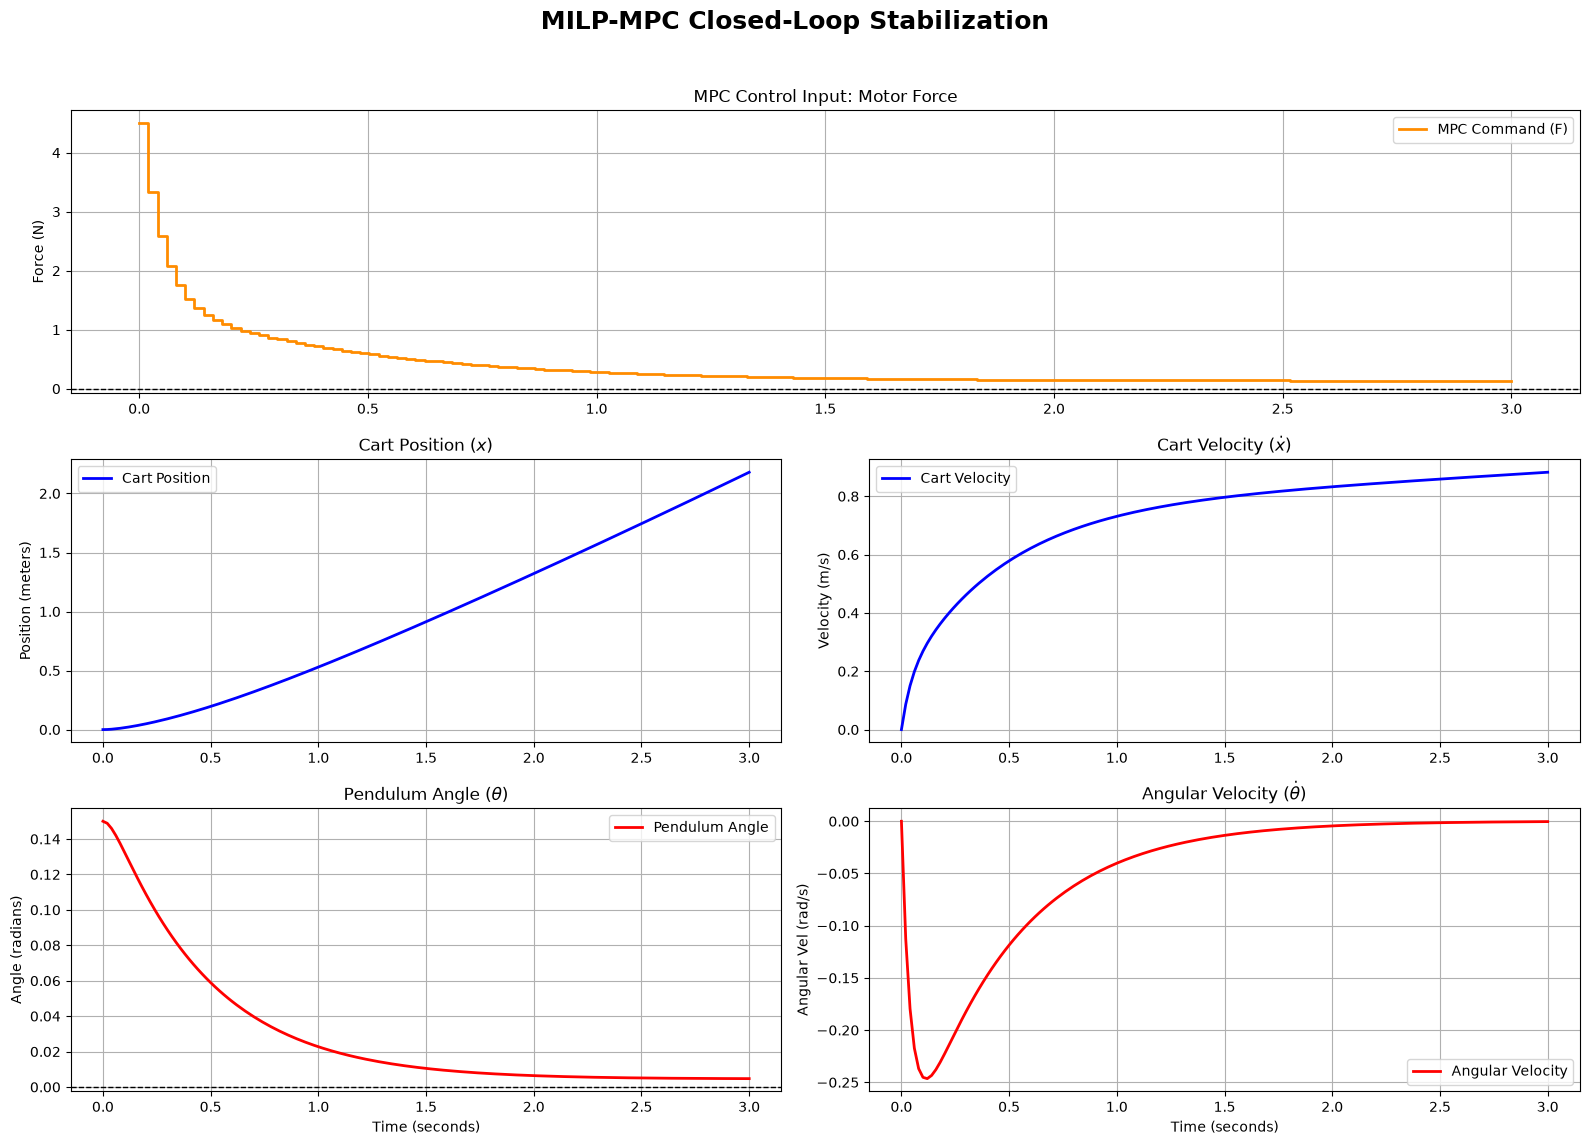

In [7]:
# ---------------------------------------------------------
# Cell 15: Final Closed-Loop MPC Simulation (10N Power)
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

m = 0.1     

sim_time = 3.0           
dt = 0.02
time_steps = int(sim_time / dt)

# Başlangıç açısı 0.15 radyan (yaklaşık 8.5 derece) - Fiziksel olarak toparlanabilir sınır
current_state = np.array([0.0, 0.0, 0.15, 0.0], dtype=np.float32)

state_trajectory = [current_state.copy()]
force_trajectory = []
solve_times = []

print(f"Starting Closed-Loop MPC Simulation for {sim_time} seconds ({time_steps} steps)...")

for step in range(time_steps):
    optimal_force, solve_time = mpc_controller.compute_control_action(current_state)
    
    # Gerçek fiziğe (RK4) uyguluyoruz
    next_state = rk4_step(current_state, optimal_force, dt)
    next_state[2] = (next_state[2] + np.pi) % (2 * np.pi) - np.pi
    
    force_trajectory.append(optimal_force)
    solve_times.append(solve_time)
    state_trajectory.append(next_state.copy())
    
    current_state = next_state
    
    if (step + 1) % 15 == 0:
        print(f"Step {step+1}/{time_steps} | Force Applied: {optimal_force:+.2f} N | Angle: {current_state[2]:.4f} rad")

state_trajectory = np.array(state_trajectory)
force_trajectory = np.array(force_trajectory)
time_axis_states = np.linspace(0, sim_time, time_steps + 1)
time_axis_force = np.linspace(0, sim_time, time_steps)

avg_solve_time = np.mean(solve_times) * 1000  
print(f"\nSimulation Finished! Average Gurobi Solve Time: {avg_solve_time:.2f} ms")

fig = plt.figure(figsize=(16, 12))
fig.suptitle('MILP-MPC Closed-Loop Stabilization', fontsize=18, fontweight='bold')

ax_force = plt.subplot2grid((3, 2), (0, 0), colspan=2)
ax_force.step(time_axis_force, force_trajectory, where='post', color='darkorange', linewidth=2, label='MPC Command (F)')
ax_force.set_title('MPC Control Input: Motor Force')
ax_force.set_ylabel('Force (N)')
ax_force.axhline(0, color='black', linewidth=1, linestyle='--')
ax_force.grid(True)
ax_force.legend()

ax_x = plt.subplot2grid((3, 2), (1, 0))
ax_x.plot(time_axis_states, state_trajectory[:, 0], label='Cart Position', color='blue', linewidth=2)
ax_x.set_title(r'Cart Position ($x$)') 
ax_x.set_ylabel('Position (meters)')
ax_x.grid(True)
ax_x.legend()

ax_xdot = plt.subplot2grid((3, 2), (1, 1))
ax_xdot.plot(time_axis_states, state_trajectory[:, 1], label='Cart Velocity', color='blue', linewidth=2)
ax_xdot.set_title(r'Cart Velocity ($\dot{x}$)')
ax_xdot.set_ylabel('Velocity (m/s)')
ax_xdot.grid(True)
ax_xdot.legend()

ax_theta = plt.subplot2grid((3, 2), (2, 0))
ax_theta.plot(time_axis_states, state_trajectory[:, 2], label='Pendulum Angle', color='red', linewidth=2)
ax_theta.set_title(r'Pendulum Angle ($\theta$)')
ax_theta.set_xlabel('Time (seconds)')
ax_theta.set_ylabel('Angle (radians)')
ax_theta.axhline(0, color='black', linewidth=1, linestyle='--')
ax_theta.grid(True)
ax_theta.legend()

ax_thetadot = plt.subplot2grid((3, 2), (2, 1))
ax_thetadot.plot(time_axis_states, state_trajectory[:, 3], label='Angular Velocity', color='red', linewidth=2)
ax_thetadot.set_title(r'Angular Velocity ($\dot{\theta}$)')
ax_thetadot.set_xlabel('Time (seconds)')
ax_thetadot.set_ylabel('Angular Vel (rad/s)')
ax_thetadot.grid(True)
ax_thetadot.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.96])
plt.show()

### Cell 16: Reusable Simulation Engine

In [8]:
# ---------------------------------------------------------
# Cell 16: Automated MPC Scenario Testing Engine
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

def run_mpc_scenario(controller, initial_state, sim_time=3.0, dt=0.02, 
                     disturbance_time=None, disturbance_force=0.0, scenario_name="MPC Test"):
    
    time_steps = int(sim_time / dt)
    current_state = np.array(initial_state, dtype=np.float32)
    
    state_trajectory = [current_state.copy()]
    force_trajectory = []
    solve_times = []
    
    print(f"--- Starting: {scenario_name} ---")
    
    for step in range(time_steps):
        t = step * dt
        
        # Calculate optimal force using MPC
        optimal_force, solve_time = controller.compute_control_action(current_state)
        
        # Add external disturbance if specified
        applied_force = optimal_force
        if disturbance_time is not None and abs(t - disturbance_time) < (dt/2):
            print(f"[*] Disturbance applied at t={t:.2f}s: {disturbance_force} N")
            applied_force += disturbance_force
            
        # Apply force to physical environment
        next_state = rk4_step(current_state, applied_force, dt)
        next_state[2] = (next_state[2] + np.pi) % (2 * np.pi) - np.pi
        
        force_trajectory.append(optimal_force) # MPC'nin ürettiği kuvveti kaydediyoruz
        solve_times.append(solve_time)
        state_trajectory.append(next_state.copy())
        
        current_state = next_state
        
    state_trajectory = np.array(state_trajectory)
    force_trajectory = np.array(force_trajectory)
    time_axis_states = np.linspace(0, sim_time, time_steps + 1)
    time_axis_force = np.linspace(0, sim_time, time_steps)
    
    avg_solve = np.mean(solve_times) * 1000
    print(f"Finished. Average Solve Time: {avg_solve:.2f} ms\n")
    
    # Plotting
    fig, axs = plt.subplots(3, 1, figsize=(14, 12))
    fig.suptitle(scenario_name, fontsize=16, fontweight='bold')
    
    # Force Plot
    axs[0].step(time_axis_force, force_trajectory, where='post', color='darkorange', linewidth=2)
    axs[0].set_title('MPC Control Input (N)')
    axs[0].axhline(0, color='black', linewidth=1, linestyle='--')
    axs[0].grid(True)
    
    # Position Plot
    axs[1].plot(time_axis_states, state_trajectory[:, 0], color='blue', linewidth=2)
    axs[1].set_title(r'Cart Position ($x$) [meters]')
    axs[1].grid(True)
    
    # Angle Plot
    axs[2].plot(time_axis_states, state_trajectory[:, 2], color='red', linewidth=2)
    axs[2].set_title(r'Pendulum Angle ($\theta$) [radians]')
    axs[2].axhline(0, color='black', linewidth=1, linestyle='--')
    axs[2].grid(True)
    
    plt.tight_layout()
    plt.show()

print("Cell 16 Executed: Scenario engine is ready.")

Cell 16 Executed: Scenario engine is ready.


--- Starting: Scenario 1: N=5 Horizon & High Position Penalty ---
Finished. Average Solve Time: 348.10 ms



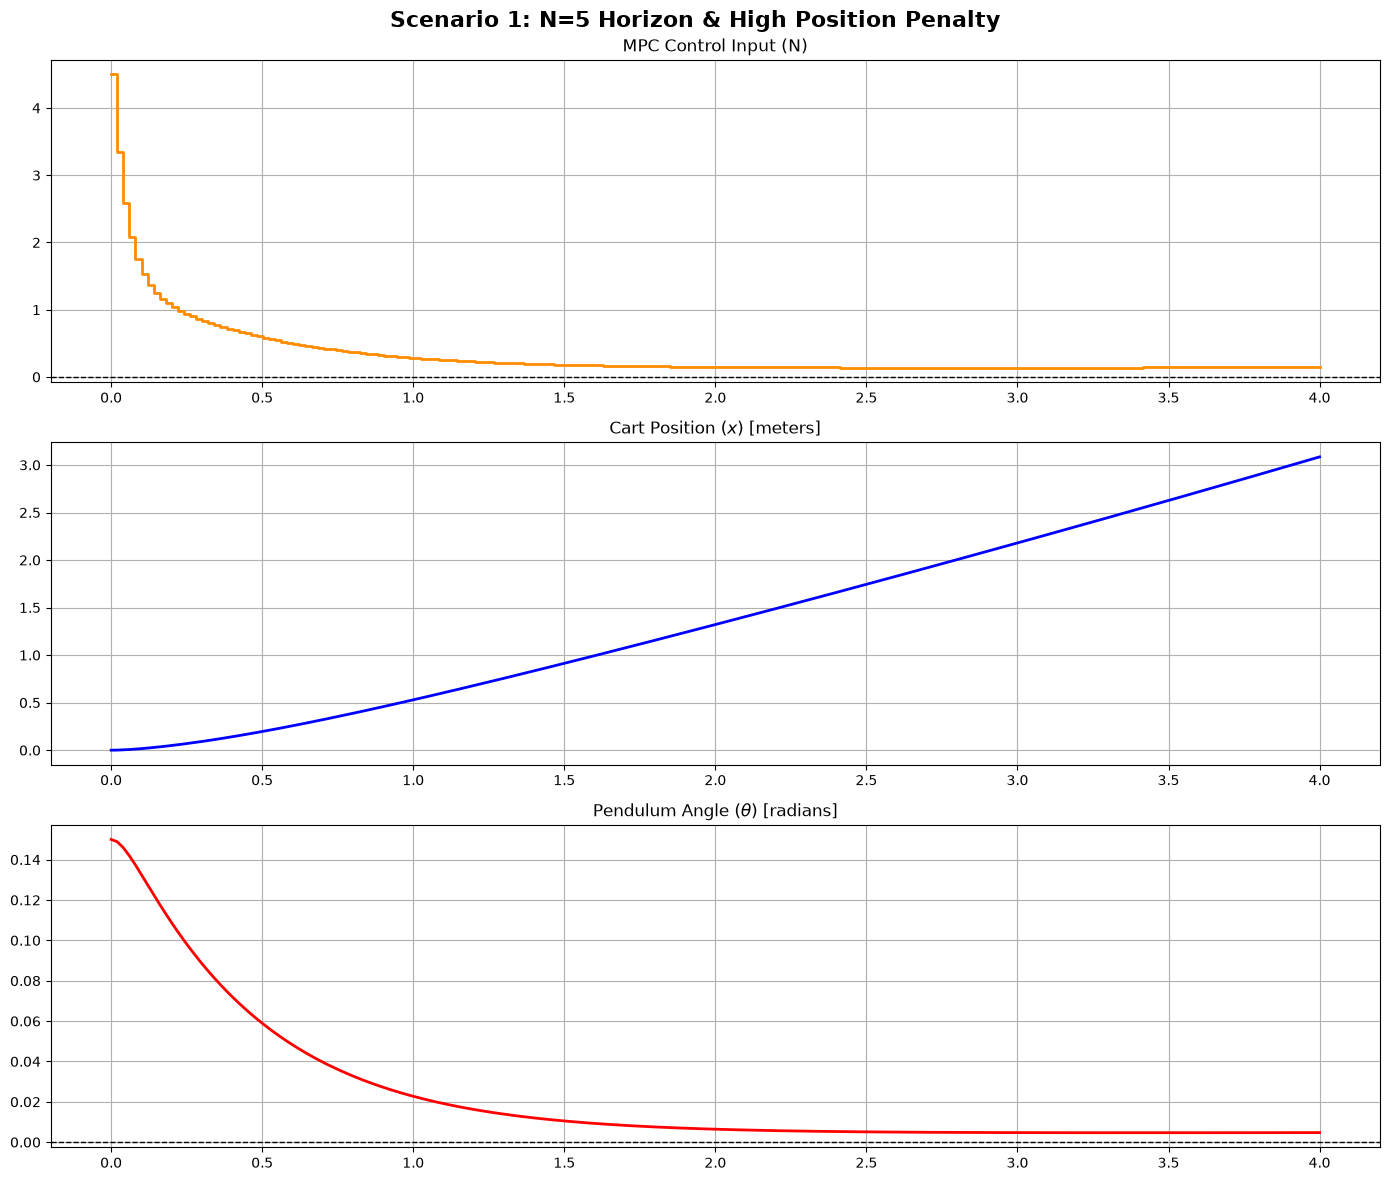

In [9]:
# ---------------------------------------------------------
# Cell 17: Scenario 1 - Extended Horizon & Position Control
# ---------------------------------------------------------
# Yeni ufuk (N=5) ile kontrolcü oluşturuyoruz
mpc_long_horizon = MILP_MPC_Controller(nn_params, N=5)

# Arabanın konum cezasını artırıyoruz (Drifti durdurmak için)
# [x_ceza, x_dot_ceza, theta_ceza, theta_dot_ceza]
mpc_long_horizon.Q = np.diag([100.0, 1.0, 500.0, 10.0]) 

# Başlangıç: Araba merkezde, Sarkaç 0.15 radyan eğik
initial_state_1 = [0.0, 0.0, 0.15, 0.0]

run_mpc_scenario(
    controller=mpc_long_horizon,
    initial_state=initial_state_1,
    sim_time=4.0,
    scenario_name="Scenario 1: N=5 Horizon & High Position Penalty"
)

--- Starting: Scenario 2: Disturbance Rejection (15N Kick at t=1.5s) ---
[*] Disturbance applied at t=1.50s: 15.0 N
Finished. Average Solve Time: 301.07 ms



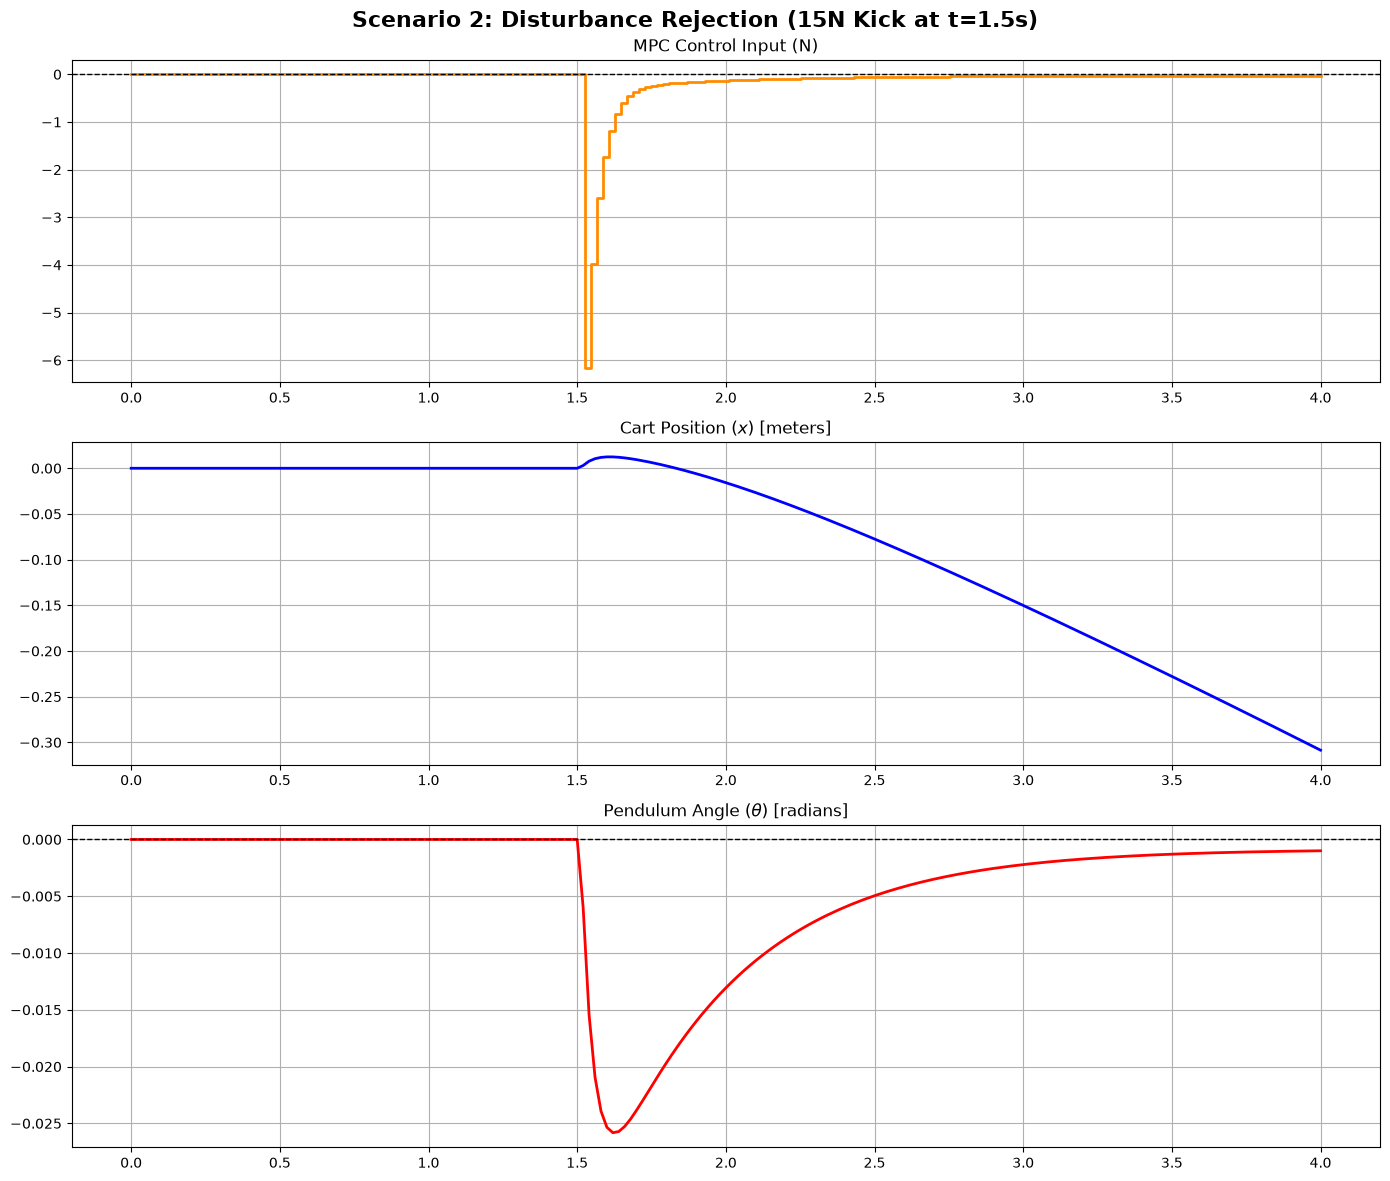

In [10]:
# ---------------------------------------------------------
# Cell 18: Scenario 2 - Sudden Wind Gust / Kick
# ---------------------------------------------------------
mpc_fast = MILP_MPC_Controller(nn_params, N=3)

# Başlangıç: Sistem tamamen dengede
initial_state_2 = [0.0, 0.0, 0.0, 0.0]

run_mpc_scenario(
    controller=mpc_fast,
    initial_state=initial_state_2,
    sim_time=4.0,
    disturbance_time=1.5,      # 1.5. saniyede tekme at!
    disturbance_force=15.0,    # 15 N'luk şok kuvvet
    scenario_name="Scenario 2: Disturbance Rejection (15N Kick at t=1.5s)"
)

--- Starting: Scenario 3: Emergency Braking from 2 m/s Velocity ---
Finished. Average Solve Time: 221.92 ms



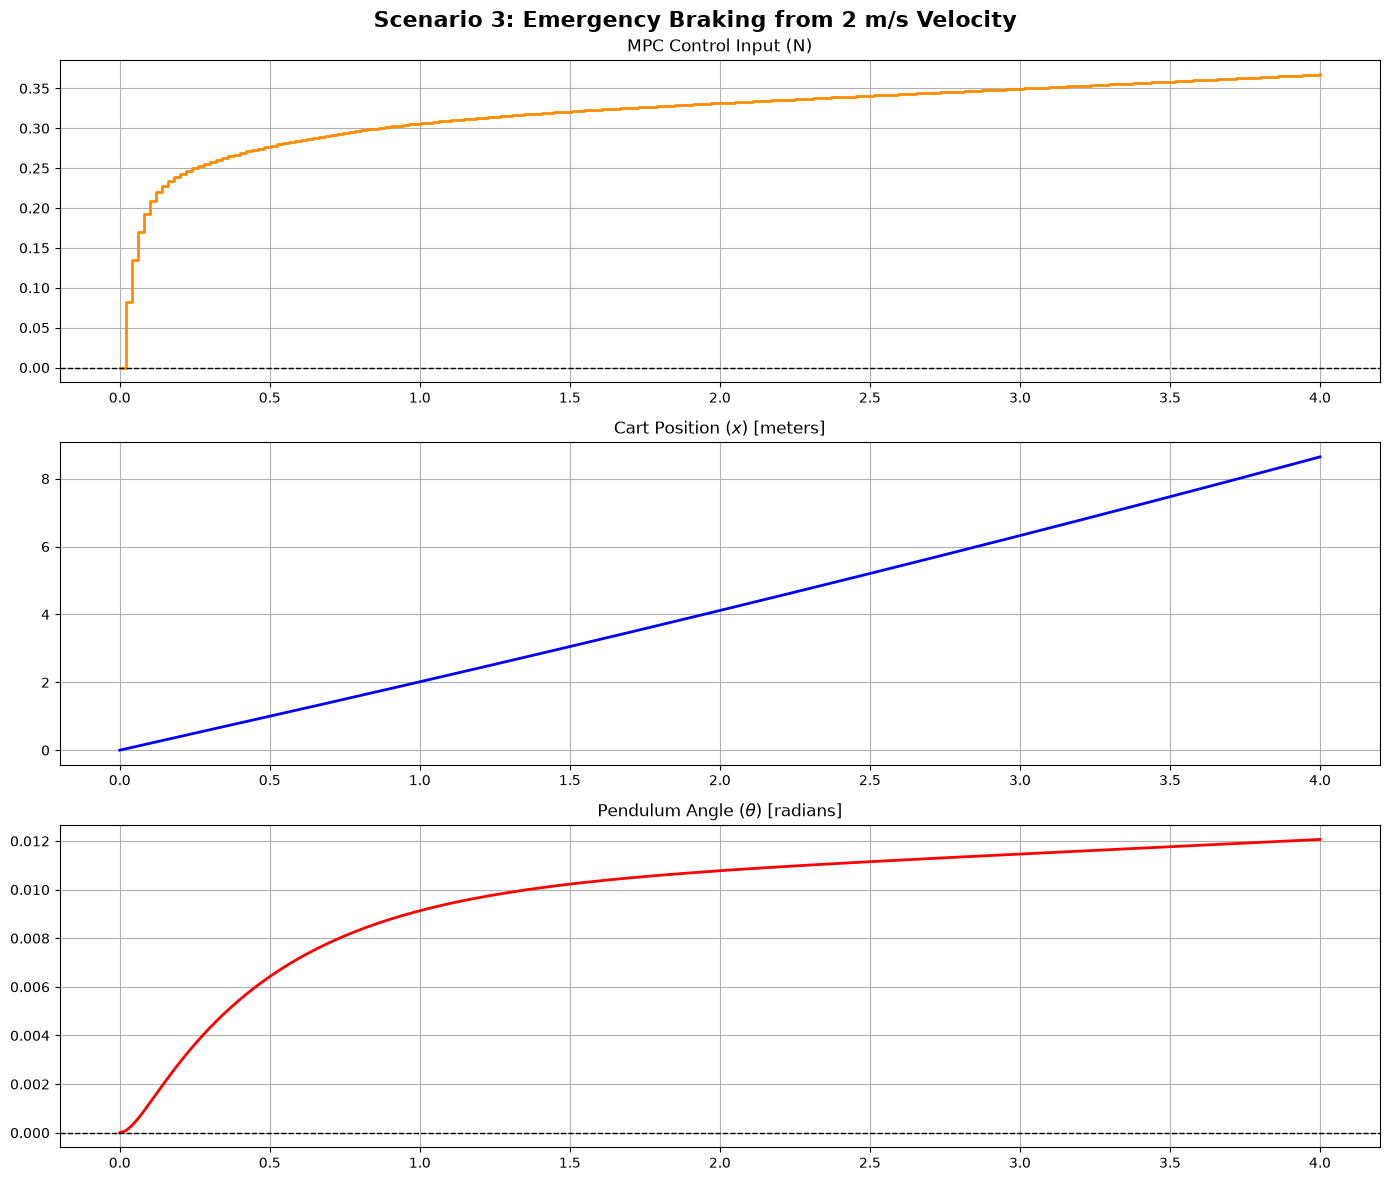

In [11]:
# ---------------------------------------------------------
# Cell 19: Scenario 3 - High Speed Braking
# ---------------------------------------------------------
mpc_fast2 = MILP_MPC_Controller(nn_params, N=3)

# Başlangıç: Araba 2 m/s hızla gidiyor, sarkaç dik!
# [x, x_dot, theta, theta_dot]
initial_state_3 = [0.0, 2.0, 0.0, 0.0]

run_mpc_scenario(
    controller=mpc_fast2,
    initial_state=initial_state_3,
    sim_time=4.0,
    scenario_name="Scenario 3: Emergency Braking from 2 m/s Velocity"
)

### Cell 20: N=10 Horizon Test with Full State Visualization

--- Starting: Scenario N=10 Horizon ---
Bekleyin... N=10 için Gurobi her adımda devasa bir MILP çözüyor.
Bu işlem bilgisayarının gücüne göre 1-2 dakika sürebilir...

Step 20/200 | Solve Time: 5314.6 ms | x: 0.14m | Theta: 0.0722rad
Step 40/200 | Solve Time: 5331.1 ms | x: 0.39m | Theta: 0.0328rad
Step 60/200 | Solve Time: 5252.3 ms | x: 0.68m | Theta: 0.0162rad
Step 80/200 | Solve Time: 5323.1 ms | x: 0.99m | Theta: 0.0093rad
Step 100/200 | Solve Time: 5308.8 ms | x: 1.32m | Theta: 0.0064rad
Step 120/200 | Solve Time: 5299.7 ms | x: 1.66m | Theta: 0.0053rad
Step 140/200 | Solve Time: 5314.7 ms | x: 2.00m | Theta: 0.0048rad
Step 160/200 | Solve Time: 5294.2 ms | x: 2.36m | Theta: 0.0047rad
Step 180/200 | Solve Time: 5402.7 ms | x: 2.72m | Theta: 0.0047rad
Step 200/200 | Solve Time: 5431.8 ms | x: 3.09m | Theta: 0.0047rad

Simülasyon Bitti! Ortalama Çözüm Süresi: 5338.52 ms


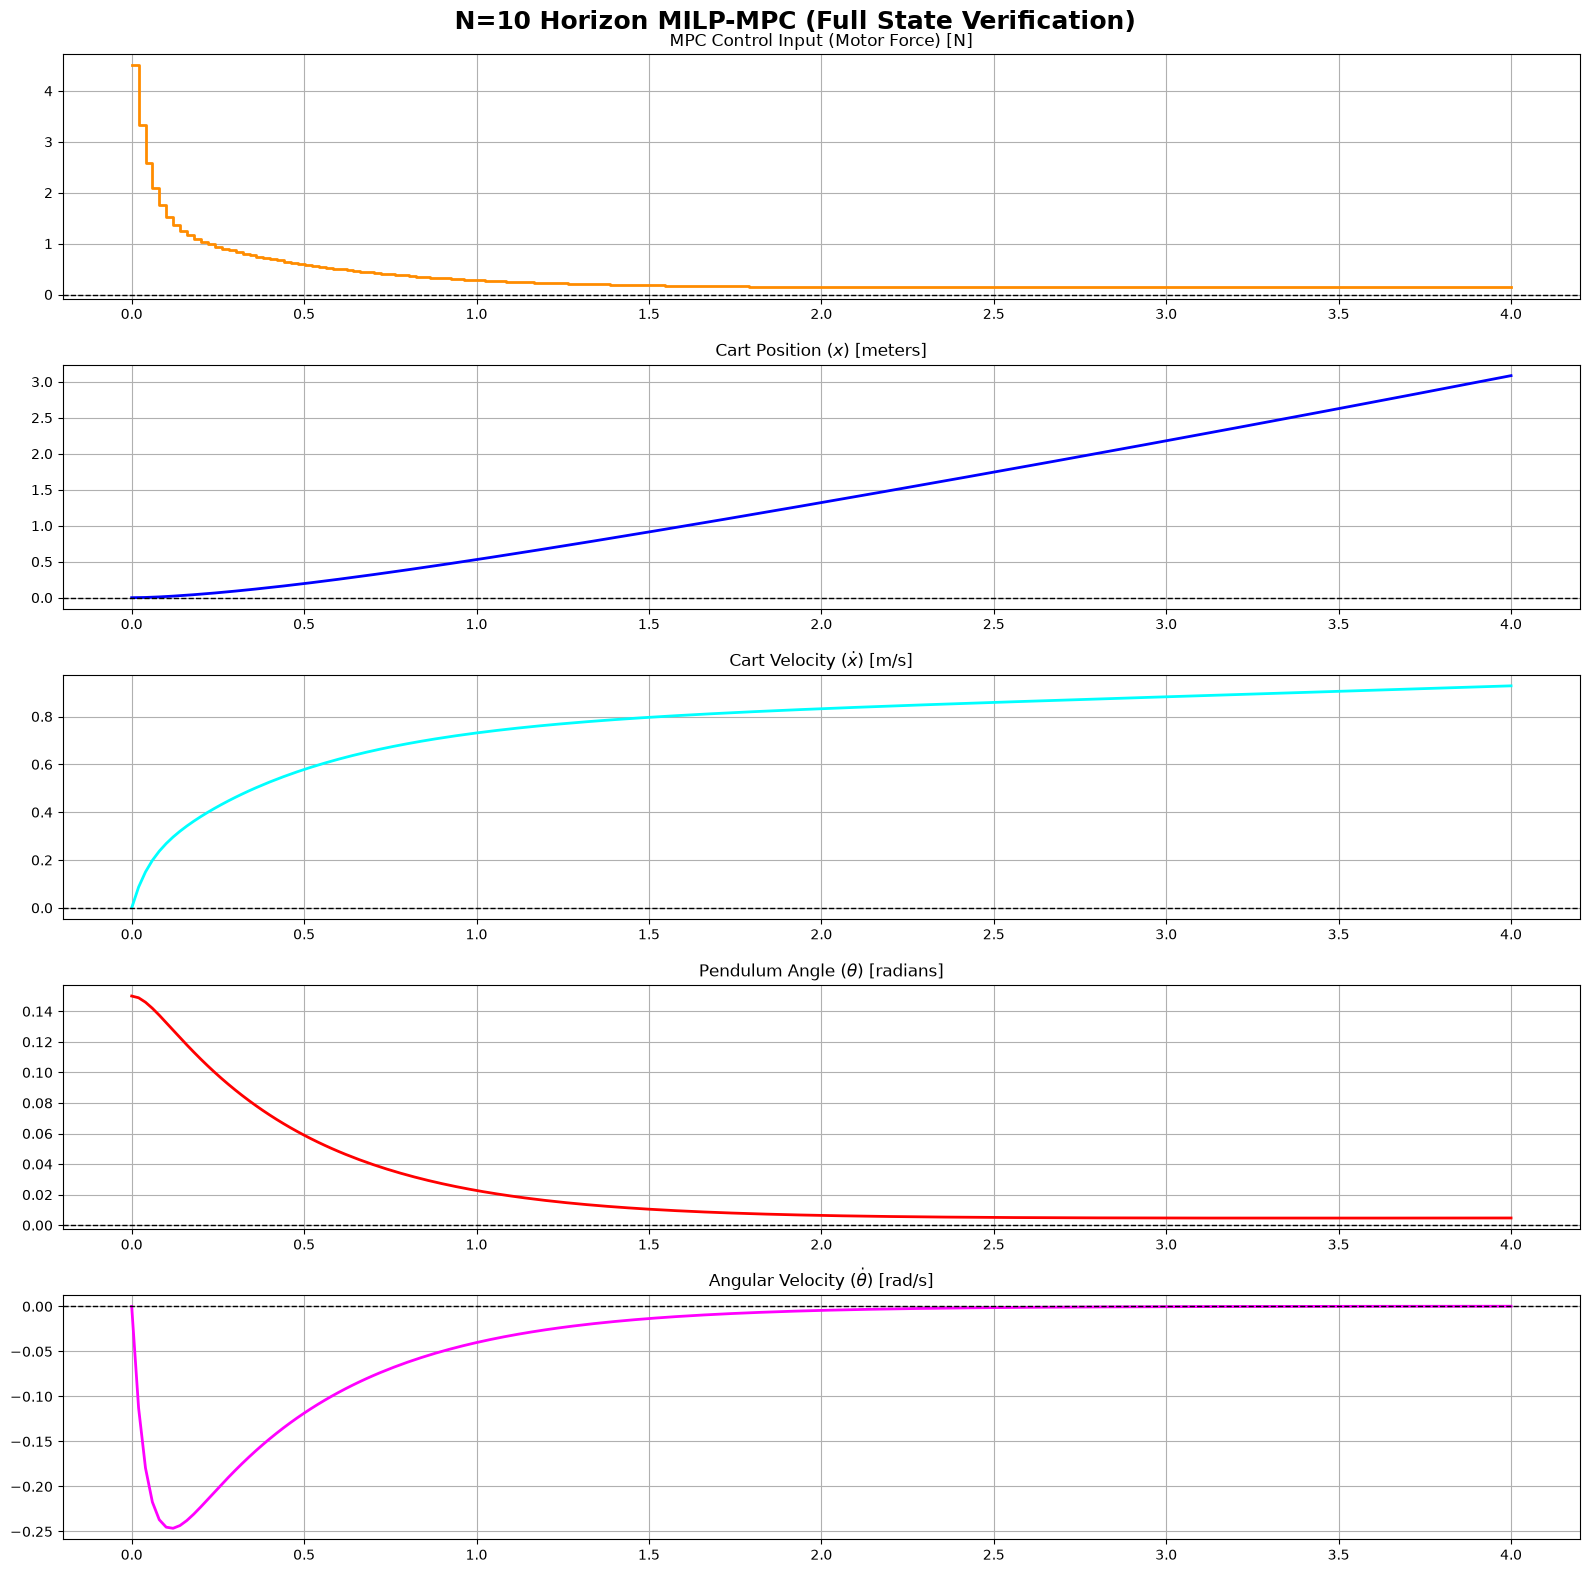

In [12]:
# ---------------------------------------------------------
# Cell 20: N=10 Horizon Test & Full State Visualization
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np
import time

# 1. N=10 ufuklu yeni kontrolcüyü tanımlıyoruz
mpc_n10 = MILP_MPC_Controller(nn_params, N=10)

# Arabanın konum cezasını yüksek tutuyoruz ki merkeze dönsün
mpc_n10.Q = np.diag([100.0, 1.0, 500.0, 10.0]) 

# Gurobi'nin N=10 ağacında kaybolmaması için süreyi genişletiyoruz (Offline test)
mpc_n10.env.setParam("TimeLimit", 5.0)

# 2. Simülasyon Kurulumu
sim_time = 4.0
dt = 0.02
time_steps = int(sim_time / dt)
current_state = np.array([0.0, 0.0, 0.15, 0.0], dtype=np.float32)

state_trajectory = [current_state.copy()]
force_trajectory = []
solve_times = []

print("--- Starting: Scenario N=10 Horizon ---")
print("Bekleyin... N=10 için Gurobi her adımda devasa bir MILP çözüyor.")
print("Bu işlem bilgisayarının gücüne göre 1-2 dakika sürebilir...\n")

for step in range(time_steps):
    optimal_force, solve_time = mpc_n10.compute_control_action(current_state)
    
    # Gerçek fiziğe (RK4) uyguluyoruz
    next_state = rk4_step(current_state, optimal_force, dt)
    next_state[2] = (next_state[2] + np.pi) % (2 * np.pi) - np.pi
    
    force_trajectory.append(optimal_force)
    solve_times.append(solve_time)
    state_trajectory.append(next_state.copy())
    
    current_state = next_state
    
    if (step + 1) % 20 == 0:
        print(f"Step {step+1}/{time_steps} | Solve Time: {solve_time*1000:.1f} ms | x: {current_state[0]:.2f}m | Theta: {current_state[2]:.4f}rad")

state_trajectory = np.array(state_trajectory)
force_trajectory = np.array(force_trajectory)
time_axis_states = np.linspace(0, sim_time, time_steps + 1)
time_axis_force = np.linspace(0, sim_time, time_steps)

avg_solve_time = np.mean(solve_times) * 1000  
print(f"\nSimülasyon Bitti! Ortalama Çözüm Süresi: {avg_solve_time:.2f} ms")

# 3. Görselleştirme (Tüm 4 Durum + Kuvvet)
fig = plt.figure(figsize=(16, 16))
fig.suptitle('N=10 Horizon MILP-MPC (Full State Verification)', fontsize=18, fontweight='bold')

# Kuvvet (Force)
ax_f = plt.subplot2grid((5, 1), (0, 0))
ax_f.step(time_axis_force, force_trajectory, where='post', color='darkorange', linewidth=2)
ax_f.set_title('MPC Control Input (Motor Force) [N]')
ax_f.axhline(0, color='black', linewidth=1, linestyle='--')
ax_f.grid(True)

# Konum (x)
ax_x = plt.subplot2grid((5, 1), (1, 0))
ax_x.plot(time_axis_states, state_trajectory[:, 0], color='blue', linewidth=2)
ax_x.set_title(r'Cart Position ($x$) [meters]')
ax_x.axhline(0, color='black', linewidth=1, linestyle='--')
ax_x.grid(True)

# Hız (x_dot)
ax_v = plt.subplot2grid((5, 1), (2, 0))
ax_v.plot(time_axis_states, state_trajectory[:, 1], color='cyan', linewidth=2)
ax_v.set_title(r'Cart Velocity ($\dot{x}$) [m/s]')
ax_v.axhline(0, color='black', linewidth=1, linestyle='--')
ax_v.grid(True)

# Açı (theta)
ax_th = plt.subplot2grid((5, 1), (3, 0))
ax_th.plot(time_axis_states, state_trajectory[:, 2], color='red', linewidth=2)
ax_th.set_title(r'Pendulum Angle ($\theta$) [radians]')
ax_th.axhline(0, color='black', linewidth=1, linestyle='--')
ax_th.grid(True)

# Açısal Hız (theta_dot)
ax_w = plt.subplot2grid((5, 1), (4, 0))
ax_w.plot(time_axis_states, state_trajectory[:, 3], color='magenta', linewidth=2)
ax_w.set_title(r'Angular Velocity ($\dot{\theta}$) [rad/s]')
ax_w.axhline(0, color='black', linewidth=1, linestyle='--')
ax_w.grid(True)

plt.tight_layout()
plt.show()

### Cell 21: Updating Controller to Track Lyapunov Cost

In [15]:
# ---------------------------------------------------------
# Cell 21: MILP-MPC Controller with Fast Lyapunov Tracking
# ---------------------------------------------------------
import gurobipy as gp
from gurobipy import GRB
import numpy as np
import time

class MILP_MPC_Lyapunov:
    def __init__(self, nn_params, N=3): # Reduced N to 3 for instant feasible solutions
        self.nn_params = nn_params
        self.N = N
        self.Q = np.diag([10.0, 1.0, 500.0, 10.0])
        self.R = 1.0
        
        self.env = gp.Env(empty=True)
        self.env.setParam("OutputFlag", 0)
        self.env.setParam("TimeLimit", 0.5)
        self.env.setParam("MIPGap", 0.1)
        self.env.setParam("MIPFocus", 1) # CRITICAL: Forces Gurobi to find feasible solutions quickly
        self.env.start()
        
    def _add_relu_layer(self, model, input_vars, W, b, step, layer_name):
        out_dim, in_dim = W.shape
        z_hat = model.addVars(out_dim, lb=-GRB.INFINITY, name=f"{layer_name}_zhat_{step}")
        z = model.addVars(out_dim, lb=0.0, name=f"{layer_name}_z_{step}")
        zero_var = model.addVar(lb=0.0, ub=0.0, name=f"{layer_name}_zero_{step}")
        
        for i in range(out_dim):
            expr = gp.quicksum(W[i, j] * input_vars[j] for j in range(in_dim)) + b[i]
            model.addConstr(z_hat[i] == expr, name=f"{layer_name}_lin_{step}_{i}")
            model.addGenConstrMax(z[i], [z_hat[i], zero_var], name=f"{layer_name}_relu_{step}_{i}")
            
        return z

    def compute_control_action(self, current_state):
        start_time = time.time()
        mpc_model = gp.Model("InvertedPendulum_MPC", env=self.env)
        
        lb_bounds = [-5.0, -10.0, -3.15, -20.0]
        ub_bounds = [ 5.0,  10.0,  3.15,  20.0]
        
        x_var = mpc_model.addVars(self.N + 1, 4, lb=-GRB.INFINITY, name="x")
        for k in range(self.N + 1):
            for i in range(4):
                x_var[k, i].lb = lb_bounds[i]
                x_var[k, i].ub = ub_bounds[i]
                
        u_var = mpc_model.addVars(self.N, lb=-10.0, ub=10.0, name="u")
        
        for i in range(4):
            mpc_model.addConstr(x_var[0, i] == current_state[i], name=f"init_state_{i}")
            
        cost_expr = 0
        for k in range(self.N):
            for i in range(4):
                cost_expr += self.Q[i, i] * (x_var[k, i] * x_var[k, i])
            cost_expr += self.R * (u_var[k] * u_var[k])
            
            nn_input = [x_var[k, 0], x_var[k, 1], x_var[k, 2], x_var[k, 3], u_var[k]]
            z1 = self._add_relu_layer(mpc_model, nn_input, self.nn_params['W0'], self.nn_params['b0'], k, "L1")
            z2 = self._add_relu_layer(mpc_model, z1, self.nn_params['W1'], self.nn_params['b1'], k, "L2")
            
            delta = mpc_model.addVars(4, lb=-GRB.INFINITY, name=f"delta_{k}")
            for i in range(4):
                expr = gp.quicksum(self.nn_params['W2'][i, j] * z2[j] for j in range(64)) + self.nn_params['b2'][i]
                mpc_model.addConstr(delta[i] == expr, name=f"delta_eq_{k}_{i}")
                mpc_model.addConstr(x_var[k+1, i] == x_var[k, i] + delta[i], name=f"dyn_update_{k}_{i}")
                
        for i in range(4):
            cost_expr += self.Q[i, i] * (x_var[self.N, i] * x_var[self.N, i])
            
        mpc_model.setObjective(cost_expr, GRB.MINIMIZE)
        mpc_model.optimize()
        
        solve_time = time.time() - start_time
        
        if mpc_model.SolCount > 0:
            return u_var[0].X, solve_time, mpc_model.ObjVal
        else:
            fallback_force = np.clip((30.0 * current_state[2]) + (10.0 * current_state[3]), -10.0, 10.0)
            return fallback_force, solve_time, None

print("Cell 21 Executed: Lyapunov Cost Extractor is ready.")

Cell 21 Executed: Lyapunov Cost Extractor is ready.


Running Lyapunov Stability Simulation...
Simulation Completed. Plotting Lyapunov Cost...


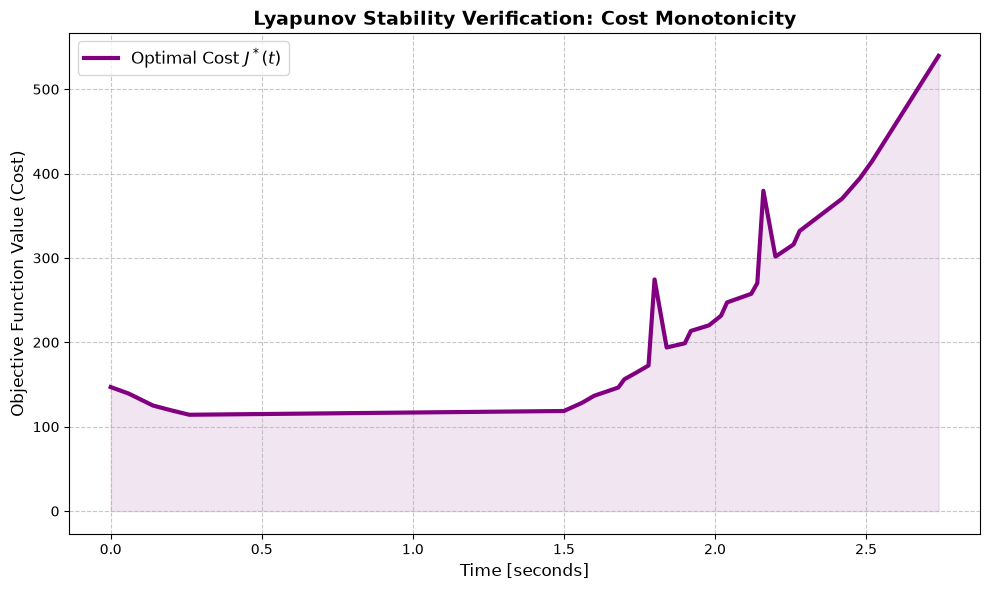

In [16]:
# ---------------------------------------------------------
# Cell 22: Lyapunov Stability Verification Test
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# Initializing with N=3 for real-time capability
lyapunov_controller = MILP_MPC_Lyapunov(nn_params, N=3)

sim_time = 3.0
dt = 0.02
time_steps = int(sim_time / dt)

current_state = np.array([0.0, 0.0, 0.15, 0.0], dtype=np.float32)

cost_trajectory = []
time_axis_cost = []

print("Running Lyapunov Stability Simulation...")

for step in range(time_steps):
    t = step * dt
    optimal_force, solve_time, optimal_cost = lyapunov_controller.compute_control_action(current_state)
    
    # Store objective value if Gurobi found a feasible solution
    if optimal_cost is not None:
        cost_trajectory.append(optimal_cost)
        time_axis_cost.append(t)
        
    next_state = rk4_step(current_state, optimal_force, dt)
    next_state[2] = (next_state[2] + np.pi) % (2 * np.pi) - np.pi
    current_state = next_state

print("Simulation Completed. Plotting Lyapunov Cost...")

plt.figure(figsize=(10, 6))
plt.plot(time_axis_cost, cost_trajectory, color='purple', linewidth=3, label=r'Optimal Cost $J^*(t)$')
plt.title('Lyapunov Stability Verification: Cost Monotonicity', fontsize=14, fontweight='bold')
plt.xlabel('Time [seconds]', fontsize=12)
plt.ylabel('Objective Function Value (Cost)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.fill_between(time_axis_cost, cost_trajectory, 0, color='purple', alpha=0.1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

### Cell 22: Pendulum-Only Lyapunov Stability Verification

Running Pendulum-Only Lyapunov Stability Simulation...
Cart drift penalties are ignored. Focusing strictly on pendulum balance.
Simulation Completed. Plotting Isolated Lyapunov Cost...


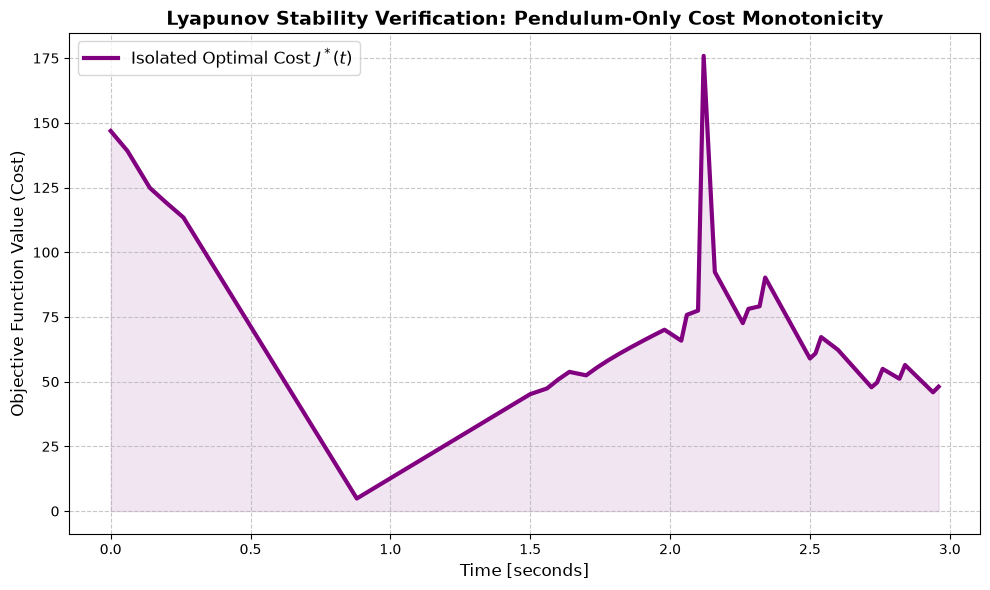

In [17]:
# ---------------------------------------------------------
# Cell 22: Pendulum-Only Lyapunov Stability Verification
# ---------------------------------------------------------
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize the controller with N=3 for fast feasible solutions
lyapunov_controller = MILP_MPC_Lyapunov(nn_params, N=3)

# 2. CRITICAL OVERRIDE: Set cart position (x) and velocity (x_dot) penalties to 0.0
# This isolates the objective function to measure ONLY the pendulum's stability (theta, theta_dot)
lyapunov_controller.Q = np.diag([0.0, 0.0, 500.0, 10.0])

# 3. Simulation Setup
sim_time = 3.0
dt = 0.02
time_steps = int(sim_time / dt)

# Start from an unstable angle (0.15 rad) to observe the mathematical decay
current_state = np.array([0.0, 0.0, 0.15, 0.0], dtype=np.float32)

cost_trajectory = []
time_axis_cost = []

print("Running Pendulum-Only Lyapunov Stability Simulation...")
print("Cart drift penalties are ignored. Focusing strictly on pendulum balance.")

# 4. Control Loop
for step in range(time_steps):
    t = step * dt
    optimal_force, solve_time, optimal_cost = lyapunov_controller.compute_control_action(current_state)
    
    # Store objective value if Gurobi found a feasible solution
    if optimal_cost is not None:
        cost_trajectory.append(optimal_cost)
        time_axis_cost.append(t)
        
    next_state = rk4_step(current_state, optimal_force, dt)
    next_state[2] = (next_state[2] + np.pi) % (2 * np.pi) - np.pi
    current_state = next_state

print("Simulation Completed. Plotting Isolated Lyapunov Cost...")

# 5. Plotting
plt.figure(figsize=(10, 6))
plt.plot(time_axis_cost, cost_trajectory, color='purple', linewidth=3, label=r'Isolated Optimal Cost $J^*(t)$')
plt.title('Lyapunov Stability Verification: Pendulum-Only Cost Monotonicity', fontsize=14, fontweight='bold')
plt.xlabel('Time [seconds]', fontsize=12)
plt.ylabel('Objective Function Value (Cost)', fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.7)
plt.fill_between(time_axis_cost, cost_trajectory, 0, color='purple', alpha=0.1)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()